In [3]:
pip install ollama

In [13]:
import ollama
import pandas as pd
import time
import random
import json
import re
from tqdm import tqdm

# ==================== КАТЕГОРИИ МЕСТ (сокращённый список для примера) ====================

VENUE_TYPES = [
    'Sauna', 'Convention center', 'Cafe', 'Museum', 'Spa', 'Zoo',
       'Training center', 'Concert hall', 'Pool hall',
       'Thai massage therapist', 'Performing arts theater',
       "Children's theater", 'Fast food restaurant', 'Movie theater',
       'Portrait studio', 'Restaurant', 'Bar', 'Computer club',
       'Computer training school', 'Sauna store', 'Party store',
       'Photography studio', 'Coffee shop', 'Tennis club',
       'Italian restaurant', 'Amusement center', 'Subway station',
       'Entertainment agency', 'Sports complex', 'Airsoft supply store',
       'Educational institution', 'Tennis court', 'Go-karting venue',
       'Public sauna', 'Farm', 'Georgian restaurant', 'Park', 'Club',
       'Photographer', 'Exhibition and trade center', 'Karaoke bar',
       "Children's cafe", 'Family restaurant', 'Night club',
       'Tattoo shop', 'Day care center', 'Pet store', 'Social club',
       'Coworking space', 'Corporate office', 'Hotel', 'Botanical garden',
       'Historical landmark', 'Garden', 'Movie studio',
       'Picture frame shop', 'Modern art museum', 'Country club',
       'Leisure center', 'Hypermarket', 'Day spa', 'Baths and saunas',
       'Public bath', 'Observatory', 'Event planner', 'Hookah bar',
       'Amusement park ride', 'Amusement park',
       "Children's amusement center", 'Tram stop', 'Bar & grill',
       'Bowling alley', 'Spa and health club',
       'Eastern European restaurant', 'Gym', 'University',
       'Motorsports store', 'Transport hub', 'Ecological park',
       'City park', 'Pool billard club', 'Billiards supply store',
       'Arboretum', 'Model portfolio studio', 'Bowling club', 'Stand bar',
       'Tour agency', 'Bowling supply shop', 'American restaurant',
       'Business center', 'Vietnamese restaurant',
       'Lebanese restaurant', 'Russian restaurant', 'Banquet hall',
       'Aquatic center', 'Art gallery', 'Opera house', 'Army museum',
       'Cultural center', 'European restaurant', 'Swimming pool',
       'Recording studio', 'Breakfast restaurant', 'Halal restaurant',
       'Tea house', 'Small plates restaurant', 'Skatepark',
       'Escape room center', 'Transit stop', 'Ice skating club',
       'Golf club', 'Sports school', 'Rock climbing gym',
       'Live music bar', 'Coffee stand', 'Art museum',
       'Photography service', 'Japanese restaurant',
       'Commercial photographer', 'Aquarium', 'Planetarium', 'Market',
       'Adult entertainment club', 'Dance club',
       'Environmental organization', 'Internet cafe',
       'Historical place museum', 'Pizza restaurant',
       'Dessert restaurant', 'Art studio', 'Mexican restaurant',
       'Sports club', 'Monastery', 'Hiking area', 'Indoor playground',
       'Jazz club', 'Stadium', 'Clothing store', 'Souvenir store',
       'Science museum', 'Cafeteria', 'Art cafe', 'Fitness center',
       'Health spa', 'Recreation center', 'Ice skating rink',
       'IMAX theater', 'Live music venue', 'Passport photo processor',
       'Photo restoration service', 'Photo shop', 'Photo lab',
       'Education center', 'Photography class', 'Photography school',
       "Children's club", 'Playground', 'Football club', 'Soccer field',
       'Vegetarian restaurant', 'Landscaping supply store',
       'Western restaurant', 'Ski resort', 'Shopping mall', 'Frituur',
       'Soup restaurant', 'Hammam', 'Chinese restaurant', 'Dog breeder',
       'Health food restaurant', 'Garden center', 'Memorial estate',
       'Synagogue', 'Coffee store', 'Mountain cable car',
       'Event ticket seller', 'Sports activity location',
       'Chicken restaurant', 'Bakery', 'Russian Orthodox church',
       'Business networking company', 'Learning center',
       'Secondary school', 'Off track betting shop', 'Buffet restaurant',
       'Equestrian club', 'Gondola lift station', 'Transit station',
       'Handicraft fair', 'Condominium complex', 'Clock repair service',
       'Ice skating instructor', 'Prison', 'Train station',
       'Nature preserve', 'Telescope store', 'Hamburger restaurant',
       'Sushi restaurant', 'Medical Center', 'Deli', 'Turkish restaurant',
       'Massage therapist', 'Massage spa', 'Art school',
       'Association / Organization', 'Beach volleyball court',
       'Memorial park', 'Pan-Asian restaurant', 'Badminton court',
       'Video production service', 'Falafel restaurant',
       'French restaurant', 'Press advisory', 'Water park', 'Airport',
       'Car racing venue', 'International airport',
       'Outdoor movie theater', 'Curling hall', 'Public university',
       'City government office', 'Archaeological museum',
       'Museum of space history', 'Handicraft museum', 'History museum',
       'Table tennis club', 'Art center', 'National park',
       'General contractor', 'Cocktail bar', 'High ropes course',
       'Puppet theater', 'E-commerce service', 'Outlet mall', 'Bistro',
       'Pub', 'Sports bar', 'Athletic field', 'Historical place',
       'Theme park', 'Paintball center', 'Sauna club', 'Wildlife park',
       'Athletic park', 'Parking lot', 'Athletic track', 'Pond',
       'Wedding photographer', 'Housing development', 'Manufacturer',
       'Espresso bar', 'Adventure sports center', 'Castle',
       'Travel agency', 'Plaza', 'Short term apartment rental agency',
       'Rock climbing', 'Tourist attraction', 'Community center',
       'Erotic massage', 'Heritage preservation', 'Community garden',
       'Beauty salon', 'Asian restaurant', 'Health resort',
       'Public medical center', 'Holiday home', 'Armenian restaurant',
       'Warehouse club', 'Chess club', 'Hat shop', 'Barbecue restaurant',
       'Shawarma restaurant', 'Rock music club', 'Roller skating rink',
       'Sculpture', 'Sporting goods store', 'Cathedral',
       'Self service restaurant', 'Brewpub', 'Dance school',
       'Music school', 'Delivery Restaurant', 'Ballet theater',
       'Theater company', 'Lido', 'Thermal baths', 'Aerial photographer',
       'Table tennis facility', 'Visitor center', 'Art dealer',
       'Drawing lessons', 'War museum', 'Wellness center',
       'Fine dining restaurant', 'Super public bath',
       'Ukrainian restaurant', 'Natural goods store', 'Needlework shop',
       'Adult education school', 'Monument', "Children's party service",
       'Uzbeki restaurant', 'Board game club', 'Dinner theater',
       'Wine bar', 'Youth center', 'Public library', 'Restaurant or cafe',
       'Wrestling school', 'Cat cafe', 'Equestrian facility',
       'Repair service', 'Herbal medicine store', 'Modeling agency',
       'Airstrip', 'Landscaper', 'Music producer', 'Diner', 'Sports',
       'Shooting range', 'Outdoor sports store'
]

# ==================== ЛИЧНОСТИ ====================

PERSONAS = [
    "подросток-зумер, говорит на сленге (краш, хайп, зашквар, норм, кек)",
    "молодая мама с маленьким ребёнком",
    "серьезный человек говорит кратко и сдержанно",
    "бизнесмен, ценит статус",
    "влюблённая пара, ищет романтику",
    "турист в незнакомом городе",
    "фрилансер-интроверт",
    "компания друзей, хотят веселья, громкой музыки",
    "ребёнок, говорит простыми фразами",
    "инстаграм-блогер, ищет красивые места для фото",
    "уставший офисный сотрудник, хочет тихо поужинать",
    "спортсмен, ищет массаж, сауну или здоровую еду",
    "любитель активного отдыха",
    "грустный человек"
]

# ==================== НАСТРОЕНИЯ ====================

MOODS = [
    "восторженный, много восклицательных знаков",
    "раздражённый, жалуется на предыдущий опыт",
    "скептический, не верит, что хорошее место существует",
    "нейтральный, спокойно перечисляет требования",
    "уставший, говорит короткими фразами",
    "требовательный, использует императивы",
    "мечтательный, описывает идеальное место",
    "нерешительный, не знает чего точно хочет и пишет очень размыто"
]

# ==================== ПРОМПТ ДЛЯ МОДЕЛИ ====================

SYSTEM_PROMPT = """Ты — генератор данных. Твоя задача — создавать реалистичные поисковые запросы пользователей о местах (кафе, рестораны, сауны и т.д.).

ВАЖНЫЕ ПРАВИЛА:
1. Запрос должен быть ТОЛЬКО НА РУССКОМ языке.
2. Учитывай личность и настроение пользователя.
3. Из запроса нужно выделить ТЕГИ — это ТОЛЬКО слова или короткие фразы, которые описывают АТМОСФЕРУ или ИНТЕРЬЕР места.
4. Теги ДОЛЖНЫ БЫТЬ ДОСЛОВНО взяты из запроса (точное совпадение).
5. НЕ включай в теги:
   - тип заведения (кафе, ресторан, сауна и т.д.)
   - действия пользователя (посидеть, покушать, попариться)
   - местоположение (метро, улица, район)
6. ХОРОШИЕ примеры тегов: "тихое", "шумное", "уютное", "с камином", "с панорамными окнами", "романтичное", "современный интерьер", "светлое", "просторное"
7. ПЛОХИЕ примеры тегов: "кофейня", "посидеть", "невкусно", "метро", "дешёво" (это не про атмосферу)

Формат вывода — ТОЛЬКО JSON, без лишнего текста:
{"query": "текст запроса пользователя", "tags": ["тег1", "тег2", ...]}

Примеры правильных ответов:
{"query": "Хочу найти тихую кофейню с панорамными окнами", "tags": ["тихую", "с панорамными окнами"]}
{"query": "Ищу шумный бар с живой музыкой и танцполом", "tags": ["шумный", "с живой музыкой", "с танцполом"]}
{"query": "Нужно уютное местечко с камином, чтобы отметить день рождения", "tags": ["уютное местечко", "с камином"]}
{"query": "Где можно спокойно попариться, чтобы не шумно и чисто было", "tags": ["спокойно", "не шумно", "чисто"]}
"""

def build_user_prompt():
    """Создаёт разнообразный запрос для модели"""
    venue = random.choice(VENUE_TYPES)
    persona = random.choice(PERSONAS)
    mood = random.choice(MOODS)
    
    return f"""Сгенерируй поисковый запрос пользователя.

Параметры:
- Тип места: {venue}
- Личность: {persona}
- Настроение: {mood}

Требования:
1. Запрос ТОЛЬКО НА РУССКОМ языке.
2. Название типа места можно оставить на английском или перевести на русский.
3. Запрос должен звучать как живой человек, с учётом личности и настроения.
4. Обязательно опиши хотя бы 1-2 характеристики АТМОСФЕРЫ или ИНТЕРЬЕРА (тихое, шумное, уютное, светлое, с камином и т.п.).

Выдай ТОЛЬКО JSON в формате: {{"query": "...", "tags": [...]}}
"""

# ==================== ГЕНЕРАТОР ====================

def generate_record(model_name: str = 'OxW/Vikhr-Nemo-12B-Instruct-R-21-09-24:q4_K_M'):
    """Генерирует одну запись"""
    for attempt in range(3):
        try:
            response = ollama.chat(
                model=model_name,
                messages=[
                    {'role': 'system', 'content': SYSTEM_PROMPT},
                    {'role': 'user', 'content': build_user_prompt()}
                ],
                options={
                    'temperature': 0.85,
                    'num_predict': 256
                }
            )
            
            result = response['message']['content']
            
            # Ищем JSON в ответе
            start = result.find('{')
            end = result.rfind('}') + 1
            if start != -1 and end != 0:
                json_str = result[start:end]
                data = json.loads(json_str)
                
                # Фильтруем теги, оставляя только про атмосферу/интерьер
                # (модель уже обучена, но на всякий случай)
                tags = data.get('tags', [])
                # Убираем кавычки внутри тегов, если есть
                tags = [tag.strip('"\'') for tag in tags]
                
                return {
                    'user_query': data['query'],
                    'atmosphere_tags': '[' + ', '.join(tag.strip() for tag in tags) + ']'
                }
        except json.JSONDecodeError as e:
            print(f"JSON ошибка (попытка {attempt+1}): {e}")
        except Exception as e:
            print(f"Ошибка (попытка {attempt+1}): {e}")
        
        time.sleep(1)
    
    return None

# ==================== ЗАПУСК ====================

if __name__ == "__main__":
    NUM_SAMPLES = 3000  # Начните с 50 для теста
    
    print(f"🚀 Начинаю генерацию {NUM_SAMPLES} запросов...")
    print(f"📊 Типов мест: {len(VENUE_TYPES)}")
    print(f"🎭 Личностей: {len(PERSONAS)}")
    print(f"💭 Настроений: {len(MOODS)}")
    print(f"🤖 Модель: OxW/Vikhr-Nemo-12B\n")
    print("📌 Теги должны быть ТОЛЬКО про атмосферу и интерьер\n")
    
    results = []
    
    for i in tqdm(range(NUM_SAMPLES)):
        record = generate_record()
        if record:
            results.append(record)
        else:
            print(f"⚠️ Не удалось сгенерировать запрос {i+1}")
        time.sleep(0.5)
    
    # Сохраняем результат с разделителем ;
    if results:
        df = pd.DataFrame(results)
        # Сохраняем с разделителем ; и без кавычек вокруг строк
        df.to_csv('synthetic_dataset.csv', index=False, encoding='utf-8-sig', sep=';', quoting=0)
        
        print(f"\n✅ Готово! Создано {len(df)} записей")
        print(f"📁 Файл сохранён: synthetic_dataset.csv")
        print(f"📌 Разделитель: точка с запятой (;)")
        
        # Показываем примеры
        print("\n🔍 ПРИМЕРЫ СГЕНЕРИРОВАННЫХ ЗАПРОСОВ:")
        for i in range(min(5, len(df))):
            print(f"\n--- Пример {i+1} ---")
            print(f"Запрос: {df.iloc[i]['user_query']}")
            print(f"Теги:   {df.iloc[i]['atmosphere_tags']}")
    else:
        print("\n❌ Не удалось сгенерировать ни одной записи. Проверьте подключение к Ollama.")

🚀 Начинаю генерацию 3000 запросов...
📊 Типов мест: 322
🎭 Личностей: 14
💭 Настроений: 8
🤖 Модель: OxW/Vikhr-Nemo-12B

📌 Теги должны быть ТОЛЬКО про атмосферу и интерьер



 49%|████▊     | 1461/3000 [2:01:04<1:58:49,  4.63s/it]

JSON ошибка (попытка 1): Expecting property name enclosed in double quotes: line 3 column 1 (char 138)
JSON ошибка (попытка 2): Expecting ',' delimiter: line 3 column 34 (char 175)


100%|██████████| 3000/3000 [4:02:51<00:00,  4.86s/it]  


✅ Готово! Создано 3000 записей
📁 Файл сохранён: synthetic_dataset.csv
📌 Разделитель: точка с запятой (;)

🔍 ПРИМЕРЫ СГЕНЕРИРОВАННЫХ ЗАПРОСОВ:

--- Пример 1 ---
Запрос: Нужно найти тихий фотошоп с уютной атмосферой, где можно спокойно поужинать после работы!😄
Теги:   [тихый, уютной атмосферы]

--- Пример 2 ---
Запрос: Ищу магазин сувениров с красивым интерьером, чтобы не как в последний раз с этой убогой вывеской и кривыми полками. Хочу сделать классные фото для инстаграма
Теги:   [с красивым интерьером]

--- Пример 3 ---
Запрос: Мне нужно туристическое агентство, но я не знаю точно куда хочу поехать. Может быть что-то интересное для детей, где спокойно и уютно?
Теги:   [для детей, спокойно, уютно]

--- Пример 4 ---
Запрос: Ищу арт-школу для инстаграма, где будет красиво и нестандартно, чтобы больше не было как в последний раз с этими ужасными углами
Теги:   [для инстаграма, красиво, нестандартно]

--- Пример 5 ---
Запрос: Может быть где-то есть магазин для снабжения пейнтбольным обору

In [2]:
import pandas as pd
import json
import ast
from collections import Counter
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('synthetic_dataset.csv', sep=';', encoding='utf-8-sig')
print(f"   - Всего записей: {len(df)}")
print(f"   - Колонки: {', '.join(df.columns)}")
print(f"   - Пустые значения: {df.isnull().sum().sum()}")

   - Всего записей: 2999
   - Колонки: user_query, atmosphere_tags
   - Пустые значения: 0


In [6]:
df['query_length'] = df['user_query'].str.len()
df['query_words'] = df['user_query'].str.split().str.len()

print(f"ДЛИНА ЗАПРОСОВ:")
print(f"   - Средняя длина (символы): {df['query_length'].mean():.1f}")
print(f"   - Медианная длина (символы): {df['query_length'].median():.1f}")
print(f"   - Минимальная длина: {df['query_length'].min()} символов")
print(f"   - Максимальная длина: {df['query_length'].max()} символов")
print(f"   - Среднее количество слов: {df['query_words'].mean():.1f}")

ДЛИНА ЗАПРОСОВ:
   - Средняя длина (символы): 122.8
   - Медианная длина (символы): 117.0
   - Минимальная длина: 24 символов
   - Максимальная длина: 437 символов
   - Среднее количество слов: 18.8



 3. ТЕГИ (АСПЕКТЫ):
   - Всего уникальных тегов: 2555
   - Среднее количество тегов на запрос: 2.55
   - Медианное количество тегов: 2
   - Минимум тегов: 0
   - Максимум тегов: 8

   Распределение количества тегов на запрос:
      0 тег(а/ов): 48 запросов (1.6%)
      1 тег(а/ов): 314 запросов (10.5%)
      2 тег(а/ов): 1365 запросов (45.5%)
      3 тег(а/ов): 751 запросов (25.0%)
      4 тег(а/ов): 344 запросов (11.5%)
      5 тег(а/ов): 119 запросов (4.0%)
      6 тег(а/ов): 43 запросов (1.4%)
      7 тег(а/ов): 12 запросов (0.4%)
      8 тег(а/ов): 3 запросов (0.1%)

🔥 4. ТОП-20 САМЫХ ЧАСТЫХ ТЕГОВ:
    1. 'тихое' — 288 раз(а) (9.6%)
    2. 'спокойно' — 245 раз(а) (8.2%)
    3. 'тихо' — 209 раз(а) (7.0%)
    4. 'уютно' — 128 раз(а) (4.3%)
    5. 'спокойное' — 116 раз(а) (3.9%)
    6. 'тихый' — 116 раз(а) (3.9%)
    7. 'уютное' — 95 раз(а) (3.2%)
    8. 'тихий' — 91 раз(а) (3.0%)
    9. 'уютный' — 81 раз(а) (2.7%)
   10. 'без шума' — 77 раз(а) (2.6%)
   11. 'громкая музыка' — 72 раз

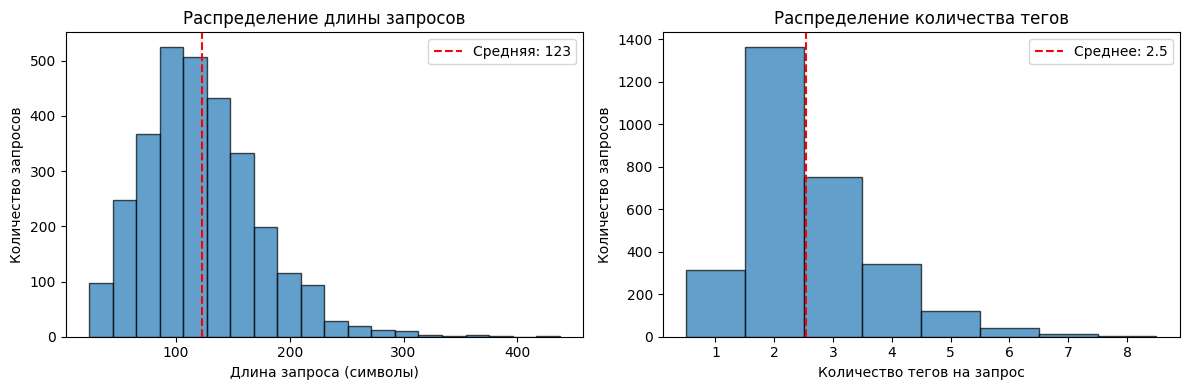

In [ ]:
def parse_tags(tag_str):
    """Преобразует строку '[тег1, тег2]' в список ['тег1', 'тег2']"""
    try:
        # Убираем квадратные скобки и пробелы
        cleaned = tag_str.strip('[]')
        if not cleaned:
            return []
        # Разделяем по запятой и убираем кавычки
        tags = [t.strip().strip('"\'') for t in cleaned.split(',')]
        return [t for t in tags if t]
    except:
        return []

df['tags_list'] = df['atmosphere_tags'].apply(parse_tags)
df['tags_count'] = df['tags_list'].apply(len)

print(f"\n 3. ТЕГИ (АСПЕКТЫ):")
print(f"   - Всего уникальных тегов: {len(set([tag for tags in df['tags_list'] for tag in tags]))}")
print(f"   - Среднее количество тегов на запрос: {df['tags_count'].mean():.2f}")
print(f"   - Медианное количество тегов: {df['tags_count'].median():.0f}")
print(f"   - Минимум тегов: {df['tags_count'].min()}")
print(f"   - Максимум тегов: {df['tags_count'].max()}")

# Распределение количества тегов
print("\n   Распределение количества тегов на запрос:")
tag_dist = df['tags_count'].value_counts().sort_index()
for count, num in tag_dist.items():
    print(f"      {count} тег(а/ов): {num} запросов ({num/len(df)*100:.1f}%)")

# ==================== 4. ТОП-20 САМЫХ ЧАСТЫХ ТЕГОВ ====================

all_tags = [tag for tags in df['tags_list'] for tag in tags]
tag_counter = Counter(all_tags)

print(f"\n🔥 4. ТОП-20 САМЫХ ЧАСТЫХ ТЕГОВ:")
for i, (tag, count) in enumerate(tag_counter.most_common(20), 1):
    print(f"   {i:2}. '{tag}' — {count} раз(а) ({count/len(df)*100:.1f}%)")

# ==================== 5. ПРИМЕРЫ ЗАПРОСОВ С РАЗНЫМ КОЛИЧЕСТВОМ ТЕГОВ ====================

print(f"\n📝 5. ПРИМЕРЫ ЗАПРОСОВ:")

print("\n   🔹 С МИНИМАЛЬНЫМ количеством тегов:")
min_tags_df = df[df['tags_count'] == df['tags_count'].min()]
if len(min_tags_df) > 0:
    row = min_tags_df.iloc[0]
    print(f"      Запрос: {row['user_query'][:100]}...")
    print(f"      Теги: {row['atmosphere_tags']}")

print("\n   🔹 С МАКСИМАЛЬНЫМ количеством тегов:")
max_tags_df = df[df['tags_count'] == df['tags_count'].max()]
if len(max_tags_df) > 0:
    row = max_tags_df.iloc[0]
    print(f"      Запрос: {row['user_query'][:100]}...")
    print(f"      Теги: {row['atmosphere_tags']}")

# ==================== 6. ПРОБЛЕМНЫЕ ЗАПИСИ (опционально) ====================

empty_tags = df[df['tags_count'] == 0]
if len(empty_tags) > 0:
    print(f"\n⚠️ 6. ПРЕДУПРЕЖДЕНИЕ:")
    print(f"   Найдено {len(empty_tags)} записей без тегов ({(len(empty_tags)/len(df))*100:.1f}%)")
    print("   Возможно, модель не смогла выделить теги для этих запросов.")

# ==================== 7. ВИЗУАЛИЗАЦИЯ (опционально) ====================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Гистограмма длины запросов
axes[0].hist(df['query_length'], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Длина запроса (символы)')
axes[0].set_ylabel('Количество запросов')
axes[0].set_title('Распределение длины запросов')
axes[0].axvline(df['query_length'].mean(), color='red', linestyle='dashed', label=f'Средняя: {df["query_length"].mean():.0f}')
axes[0].legend()

# Гистограмма количества тегов
axes[1].hist(df['tags_count'], bins=range(1, df['tags_count'].max()+2), edgecolor='black', alpha=0.7, align='left')
axes[1].set_xlabel('Количество тегов на запрос')
axes[1].set_ylabel('Количество запросов')
axes[1].set_title('Распределение количества тегов')
axes[1].axvline(df['tags_count'].mean(), color='red', linestyle='dashed', label=f'Среднее: {df["tags_count"].mean():.1f}')
axes[1].legend()

plt.tight_layout()

# ==================== 8. СОХРАНЕНИЕ ОТЧЕТА ====================

report_lines = [
    "=" * 60,
    "СТАТИСТИКА ДАТАСЕТА ДЛЯ ОБУЧЕНИЯ МОДЕЛИ",
    "=" * 60,
    f"Всего записей: {len(df)}",
    f"Средняя длина запроса: {df['query_length'].mean():.1f} символов ({df['query_words'].mean():.1f} слов)",
    f"Всего уникальных тегов: {len(tag_counter)}",
    f"Среднее количество тегов на запрос: {df['tags_count'].mean():.2f}",
    "",
    "ТОП-10 САМЫХ ЧАСТЫХ ТЕГОВ:",
]
for tag, count in tag_counter.most_common(10):
    report_lines.append(f"  '{tag}': {count} раз ({count/len(df)*100:.1f}%)")

In [9]:
import pandas as pd

# Загружаем датасет (разделитель ; )
try:
    df = pd.read_csv('synthetic_dataset.csv', sep=';', encoding='utf-8-sig')
    print(f"✅ Файл загружен. Всего записей: {len(df)}\n")
except FileNotFoundError:
    print("❌ Файл synthetic_dataset.csv не найден. Проверьте путь к файлу.")
    exit()

# Функция для проверки, является ли значение тегов пустым
def is_empty_tags(tag_value):
    # Проверяем на NaN, None, пустую строку, строку "[]" или "[ ]"
    if pd.isna(tag_value):
        return True
    if not isinstance(tag_value, str):
        tag_value = str(tag_value)
    cleaned = tag_value.strip()
    return cleaned == '' or cleaned == '[]' or cleaned == '[ ]'

# Находим записи без тегов
empty_mask = df['atmosphere_tags'].apply(is_empty_tags)
empty_records = df[empty_mask]

print(f"🔍 НАЙДЕНО ЗАПИСЕЙ БЕЗ ТЕГОВ: {len(empty_records)}\n")
print("=" * 80)

if len(empty_records) > 0:
    for idx, row in empty_records.iterrows():
        print(f"📌 ЗАПИСЬ #{idx + 1} (индекс {idx}):")
        print(f"   Запрос пользователя: {row['user_query']}")
        print(f"   Поле atmosphere_tags: {row['atmosphere_tags']}")
        print("-" * 80)
else:
    print("🎉 Отлично! Все записи содержат теги.")

✅ Файл загружен. Всего записей: 2999

🔍 НАЙДЕНО ЗАПИСЕЙ БЕЗ ТЕГОВ: 48

📌 ЗАПИСЬ #86 (индекс 85):
   Запрос пользователя: где найти магазин садовой техники для отдыха после работы
   Поле atmosphere_tags: []
--------------------------------------------------------------------------------
📌 ЗАПИСЬ #106 (индекс 105):
   Запрос пользователя: Где хороший спорт-бара для массажа?
   Поле atmosphere_tags: []
--------------------------------------------------------------------------------
📌 ЗАПИСЬ #182 (индекс 181):
   Запрос пользователя: Нужна специализированная торговая точка для садоводства, с широким ассортиментом посадочных материалов и профессиональным персоналом.
   Поле atmosphere_tags: []
--------------------------------------------------------------------------------
📌 ЗАПИСЬ #192 (индекс 191):
   Запрос пользователя: Где хорошая выпечка для ребенка?
   Поле atmosphere_tags: []
--------------------------------------------------------------------------------
📌 ЗАПИСЬ #206 (индекс 205)

In [17]:
import pandas as pd

# Загружаем датасет
df = pd.read_csv('synthetic_dataset.csv', sep=';', encoding='utf-8-sig')

# Оставляем только непустые теги
def has_valid_tags(tag_value):
    if pd.isna(tag_value):
        return False
    tag_str = str(tag_value).strip()
    # Пустые скобки или пустая строка — не подходят
    return tag_str not in ('', '[]', '[ ]')

df_clean = df[df['atmosphere_tags'].apply(has_valid_tags)]

print(f"Было записей: {len(df)}")
print(f"Осталось после чистки: {len(df_clean)}")
print(f"Удалено пустых: {len(df) - len(df_clean)}")

# Сохраняем чистый датасет
df_clean.to_csv('synthetic_dataset_clean.csv', index=False, sep=';', encoding='utf-8-sig', quoting=0)

Было записей: 2999
Осталось после чистки: 2951
Удалено пустых: 48


In [20]:
import ollama
import pandas as pd
import json
import time
import ast
from tqdm import tqdm

# ==================== МОДЕЛИ ДЛЯ ВАЛИДАЦИИ ====================

MODELS = {
    "validator": "qwen2.5:7b",
    "backup": "OxW/Vikhr-Nemo-12B-Instruct-R-21-09-24:q4_K_M"
}

VALIDATION_PROMPT = """Ты — валидатор тегов для поисковых запросов.

Запрос пользователя: "{query}"
Оригинальные теги: {original_tags}

ПРАВИЛА:
1. Теги описывают ТОЛЬКО атмосферу или интерьер места
2. НЕ включай: тип заведения (кафе, сауна, ресторан), действия (посидеть, поесть), местоположение (метро)
3. Теги ДОЛЖНЫ БЫТЬ ДОСЛОВНО из запроса
4. Удали лишние теги, добавь пропущенные

ХОРОШИЕ ТЕГИ: "тихое", "с камином", "уютное", "светлое"
ПЛОХИЕ ТЕГИ: "кофейня", "посидеть", "метро", "вкусно"

Верни ТОЛЬКО JSON: {{"corrected_tags": ["тег1", "тег2", ...]}}"""

def safe_parse_tags(tag_str):
    """Безопасно преобразует строку с тегами в список"""
    if pd.isna(tag_str) or not isinstance(tag_str, str):
        return []
    try:
        # Убираем квадратные скобки и пробелы
        cleaned = tag_str.strip('[]')
        if not cleaned:
            return []
        # Разделяем по запятой, убираем кавычки и пробелы
        tags = [t.strip().strip('"\'') for t in cleaned.split(',')]
        return [t for t in tags if t]
    except:
        return []

def filter_tags_in_query(tags, query):
    """Оставляет теги, которые дословно встречаются в запросе"""
    query_lower = query.lower()
    return [tag for tag in tags if tag.lower() in query_lower]

def validate_with_model(query, original_tags, model_name):
    """Запускает валидацию на указанной модели"""
    for attempt in range(2):
        try:
            response = ollama.chat(
                model=model_name,
                messages=[{
                    'role': 'user',
                    'content': VALIDATION_PROMPT.format(
                        query=query,
                        original_tags=original_tags
                    )
                }],
                options={'temperature': 0.0}  # Ещё строже
            )
            
            content = response['message']['content']
            start = content.find('{')
            end = content.rfind('}') + 1
            
            if start != -1 and end != 0:
                data = json.loads(content[start:end])
                # Оставляем только теги из запроса
                raw_tags = data.get('corrected_tags', [])
                return filter_tags_in_query(raw_tags, query)
        except Exception as e:
            if attempt == 0:  # Логируем только первую ошибку
                print(f"Ошибка в {model_name}: {e}")
            time.sleep(1)
    return []

def validate_dataset(df, validated_file='validated_dataset.csv'):
    """Валидация всего датасета"""
    results = []
    changed_count = 0
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Валидация"):
        query = row['user_query']
        original_tags = safe_parse_tags(row['atmosphere_tags'])
        
        # Валидация
        validated_tags = validate_with_model(query, original_tags, MODELS["validator"])
        
        if not validated_tags:
            validated_tags = validate_with_model(query, original_tags, MODELS["backup"])
        
        if not validated_tags and original_tags:
            validated_tags = filter_tags_in_query(original_tags, query)
        
        # Проверяем, изменились ли теги
        if set(original_tags) != set(validated_tags):
            changed_count += 1
        
        results.append({
            'user_query': query,
            'original_tags': str(original_tags),
            'validated_tags': str(validated_tags)
        })
    
    # Сохраняем результат
    result_df = pd.DataFrame(results)
    result_df.to_csv(validated_file, index=False, sep=';', encoding='utf-8-sig')
    
    print(f"\n Валидация завершена! Результат в {validated_file}")
    print(f" Изменено записей: {changed_count} из {len(results)} ({changed_count/len(results)*100:.1f}%)")
    
    return result_df

if __name__ == "__main__":
    df = pd.read_csv('synthetic_dataset_clean.csv', sep=';', encoding='utf-8-sig')
    validated = validate_dataset(df, 'synthetic_dataset_validated.csv')

Валидация: 100%|██████████| 2951/2951 [4:30:33<00:00,  5.50s/it]  



✅ Валидация завершена! Результат в synthetic_dataset_validated.csv
📊 Изменено записей: 2271 из 2951 (77.0%)


Создадим еще немного строк с другим промтом, чтобы было более подробное описание мест:

In [ ]:
import ollama
import pandas as pd
import json
import time
import random
from tqdm import tqdm

# ==================== КАТЕГОРИИ МЕСТ (для разнообразия) ====================
VENUE_TYPES = [
    'Sauna', 'Convention center', 'Cafe', 'Museum', 'Spa', 'Zoo',
       'Training center', 'Concert hall', 'Pool hall',
       'Thai massage therapist', 'Performing arts theater',
       "Children's theater", 'Fast food restaurant', 'Movie theater',
       'Portrait studio', 'Restaurant', 'Bar', 'Computer club',
       'Computer training school', 'Sauna store', 'Party store',
       'Photography studio', 'Coffee shop', 'Tennis club',
       'Italian restaurant', 'Amusement center', 'Subway station',
       'Entertainment agency', 'Sports complex', 'Airsoft supply store',
       'Educational institution', 'Tennis court', 'Go-karting venue',
       'Public sauna', 'Farm', 'Georgian restaurant', 'Park', 'Club',
       'Photographer', 'Exhibition and trade center', 'Karaoke bar',
       "Children's cafe", 'Family restaurant', 'Night club',
       'Tattoo shop', 'Day care center', 'Pet store', 'Social club',
       'Coworking space', 'Corporate office', 'Hotel', 'Botanical garden',
       'Historical landmark', 'Garden', 'Movie studio',
       'Picture frame shop', 'Modern art museum', 'Country club',
       'Leisure center', 'Hypermarket', 'Day spa', 'Baths and saunas',
       'Public bath', 'Observatory', 'Event planner', 'Hookah bar',
       'Amusement park ride', 'Amusement park',
       "Children's amusement center", 'Tram stop', 'Bar & grill',
       'Bowling alley', 'Spa and health club',
       'Eastern European restaurant', 'Gym', 'University',
       'Motorsports store', 'Transport hub', 'Ecological park',
       'City park', 'Pool billard club', 'Billiards supply store',
       'Arboretum', 'Model portfolio studio', 'Bowling club', 'Stand bar',
       'Tour agency', 'Bowling supply shop', 'American restaurant',
       'Business center', 'Vietnamese restaurant',
       'Lebanese restaurant', 'Russian restaurant', 'Banquet hall',
       'Aquatic center', 'Art gallery', 'Opera house', 'Army museum',
       'Cultural center', 'European restaurant', 'Swimming pool',
       'Recording studio', 'Breakfast restaurant', 'Halal restaurant',
       'Tea house', 'Small plates restaurant', 'Skatepark',
       'Escape room center', 'Transit stop', 'Ice skating club',
       'Golf club', 'Sports school', 'Rock climbing gym',
       'Live music bar', 'Coffee stand', 'Art museum',
       'Photography service', 'Japanese restaurant',
       'Commercial photographer', 'Aquarium', 'Planetarium', 'Market',
       'Adult entertainment club', 'Dance club',
       'Environmental organization', 'Internet cafe',
       'Historical place museum', 'Pizza restaurant',
       'Dessert restaurant', 'Art studio', 'Mexican restaurant',
       'Sports club', 'Monastery', 'Hiking area', 'Indoor playground',
       'Jazz club', 'Stadium', 'Clothing store', 'Souvenir store',
       'Science museum', 'Cafeteria', 'Art cafe', 'Fitness center',
       'Health spa', 'Recreation center', 'Ice skating rink',
       'IMAX theater', 'Live music venue', 'Passport photo processor',
       'Photo restoration service', 'Photo shop', 'Photo lab',
       'Education center', 'Photography class', 'Photography school',
       "Children's club", 'Playground', 'Football club', 'Soccer field',
       'Vegetarian restaurant', 'Landscaping supply store',
       'Western restaurant', 'Ski resort', 'Shopping mall', 'Frituur',
       'Soup restaurant', 'Hammam', 'Chinese restaurant', 'Dog breeder',
       'Health food restaurant', 'Garden center', 'Memorial estate',
       'Synagogue', 'Coffee store', 'Mountain cable car',
       'Event ticket seller', 'Sports activity location',
       'Chicken restaurant', 'Bakery', 'Russian Orthodox church',
       'Business networking company', 'Learning center',
       'Secondary school', 'Off track betting shop', 'Buffet restaurant',
       'Equestrian club', 'Gondola lift station', 'Transit station',
       'Handicraft fair', 'Condominium complex', 'Clock repair service',
       'Ice skating instructor', 'Prison', 'Train station',
       'Nature preserve', 'Telescope store', 'Hamburger restaurant',
       'Sushi restaurant', 'Medical Center', 'Deli', 'Turkish restaurant',
       'Massage therapist', 'Massage spa', 'Art school',
       'Association / Organization', 'Beach volleyball court',
       'Memorial park', 'Pan-Asian restaurant', 'Badminton court',
       'Video production service', 'Falafel restaurant',
       'French restaurant', 'Press advisory', 'Water park', 'Airport',
       'Car racing venue', 'International airport',
       'Outdoor movie theater', 'Curling hall', 'Public university',
       'City government office', 'Archaeological museum',
       'Museum of space history', 'Handicraft museum', 'History museum',
       'Table tennis club', 'Art center', 'National park',
       'General contractor', 'Cocktail bar', 'High ropes course',
       'Puppet theater', 'E-commerce service', 'Outlet mall', 'Bistro',
       'Pub', 'Sports bar', 'Athletic field', 'Historical place',
       'Theme park', 'Paintball center', 'Sauna club', 'Wildlife park',
       'Athletic park', 'Parking lot', 'Athletic track', 'Pond',
       'Wedding photographer', 'Housing development', 'Manufacturer',
       'Espresso bar', 'Adventure sports center', 'Castle',
       'Travel agency', 'Plaza', 'Short term apartment rental agency',
       'Rock climbing', 'Tourist attraction', 'Community center',
       'Erotic massage', 'Heritage preservation', 'Community garden',
       'Beauty salon', 'Asian restaurant', 'Health resort',
       'Public medical center', 'Holiday home', 'Armenian restaurant',
       'Warehouse club', 'Chess club', 'Hat shop', 'Barbecue restaurant',
       'Shawarma restaurant', 'Rock music club', 'Roller skating rink',
       'Sculpture', 'Sporting goods store', 'Cathedral',
       'Self service restaurant', 'Brewpub', 'Dance school',
       'Music school', 'Delivery Restaurant', 'Ballet theater',
       'Theater company', 'Lido', 'Thermal baths', 'Aerial photographer',
       'Table tennis facility', 'Visitor center', 'Art dealer',
       'Drawing lessons', 'War museum', 'Wellness center',
       'Fine dining restaurant', 'Super public bath',
       'Ukrainian restaurant', 'Natural goods store', 'Needlework shop',
       'Adult education school', 'Monument', "Children's party service",
       'Uzbeki restaurant', 'Board game club', 'Dinner theater',
       'Wine bar', 'Youth center', 'Public library', 'Restaurant or cafe',
       'Wrestling school', 'Cat cafe', 'Equestrian facility',
       'Repair service', 'Herbal medicine store', 'Modeling agency',
       'Airstrip', 'Landscaper', 'Music producer', 'Diner', 'Sports',
       'Shooting range', 'Outdoor sports store'
]

# ==================== ДЕТАЛЬНЫЙ ПРОМПТ ====================
DETAILED_GENERATION_PROMPT = """Ты — генератор реалистичных поисковых запросов пользователей о местах (кафе, рестораны, парки, сауны, музеи).

Задача: создать запрос от первого лица с детальным описанием атмосферы и интерьера.

Правила:
1. Язык — русский, живой, естественный.
2. Опиши:
   - АТМОСФЕРУ (тихо/шумно, романтично/энергично, уютно/строго, уединённо/людно)
   - ИНТЕРЬЕР (деревянные столы, мягкие кресла, панорамные окна, свечи, камин, неон, открытая кухня)
   - ОСВЕЩЕНИЕ (приглушённый свет, много света, торшеры, бра)
   - ЗВУКИ (живая музыка, тишина, электроника, разговоры)
3. Длина: 2-4 предложения.

Примеры хороших запросов:

Пример 1 (романтичное кафе):
"Ищу уютное кафе с приглушённым светом и мягкими диванами, чтобы спокойно поужинать вдвоём под живую акустическую музыку. Хочется, чтобы было не шумно, а на столах стояли свечи."

Пример 2 (шумный бар):
"Нужен модный бар с открытой кирпичной стеной и неоновой подсветкой, где играет электронная музыка и можно потанцевать в толпе. Чтобы атмосфера была энерджайзер, не для скучных разговоров."

Пример 3 (спокойная сауна):
"Хочу попариться в деревянной сауне с панорамным окном в лес, где вместо музыки — тишина и запах эвкалипта. Чтобы внутри было просторно, светло и никого, кроме нас с парой друзей."

Пример 4 (коворкинг):
"Ищу коворкинг с большими окнами и высокими потолками, где много естественного света и розеток у каждого стола. Чтобы можно было уединиться в кресле-мешке и работалось спокойно, без лишнего шума."

Теперь сгенерируй запрос для типа места: {venue}

Формат вывода — ТОЛЬКО JSON: {{"query": "...", "tags": [...]}}

Теги — это дословные фразы из запроса, описывающие атмосферу или интерьер (2-5 тегов).
"""

def generate_detailed_record(model_name='OxW/Vikhr-Nemo-12B-Instruct-R-21-09-24:q4_K_M'):
    """Генерирует один детальный запрос"""
    venue = random.choice(VENUE_TYPES)
    
    for attempt in range(3):
        try:
            response = ollama.chat(
                model=model_name,
                messages=[{
                    'role': 'user',
                    'content': DETAILED_GENERATION_PROMPT.format(venue=venue)
                }],
                options={
                    'temperature': 0.85,
                    'num_predict': 512  # Больше токенов для детальности
                }
            )
            
            content = response['message']['content']
            start = content.find('{')
            end = content.rfind('}') + 1
            
            if start != -1 and end != 0:
                data = json.loads(content[start:end])
                return {
                    'user_query': data['query'],
                    'atmosphere_tags': '[' + ', '.join(data.get('tags', [])) + ']'
                }
        except Exception as e:
            print(f"Ошибка (попытка {attempt+1}): {e}")
            time.sleep(1)
    
    return None

# ==================== ЗАПУСК ====================
if __name__ == "__main__":
    NUM_SAMPLES = 322  # Измените на нужное количество
    print(f"🚀 Запуск детальной генерации {NUM_SAMPLES} запросов...")
    print(f"🏷️  Типы мест: {len(VENUE_TYPES)}")
    
    results = []
    for i in tqdm(range(NUM_SAMPLES)):
        record = generate_detailed_record()
        if record:
            results.append(record)
        time.sleep(0.3)
    
    if results:
        df = pd.DataFrame(results)
        df.to_csv('detailed_queries.csv', index=False, sep=';', encoding='utf-8-sig')
        print(f"\n✅ Сохранено {len(results)} запросов в detailed_queries.csv")
        
        # Показываем пару примеров
        print("\n🔍 ПРИМЕРЫ:")
        for i in range(min(3, len(df))):
            print(f"\n--- {i+1} ---")
            print(f"Запрос: {df.iloc[i]['user_query']}")
            print(f"Теги:   {df.iloc[i]['atmosphere_tags']}")

🚀 Запуск детальной генерации 322 запросов...
🏷️  Типы мест: 322


 44%|████▍     | 141/322 [41:06<51:44, 17.15s/it]  

Ошибка (попытка 1): Expecting ',' delimiter: line 3 column 3 (char 267)


100%|██████████| 322/322 [1:32:22<00:00, 17.21s/it]



✅ Сохранено 322 запросов в detailed_queries.csv

🔍 ПРИМЕРЫ:

--- 1 ---
Запрос: Ищу астрономический планетарий с мягкими креслами, где можно уютно устроиться и наблюдать за звёздами на большом куполообразном экране. Хочется, чтобы звуки были минимальны или присутствовала приятная фоновая музыка, а освещение было немного приглушенным, создавая атмосферу глубкого космоса.
Теги:   [астрономический планетарий, мягкие кресла, звёздное небо, приглушённое свет, фоновая музыка]

--- 2 ---
Запрос: Хочу найти развлекательный центр с просторным залом для боулинга и играми виртуальной реальности. Ищу место, где царит веселая атмосфера, много народу, яркое освещение и звучит популярная музыка. Предпочтительно, чтобы было уютное кафе с мягкими креслами внутри центра.
Теги:   [развлекательный центр, боулинг, виртуальная реальность, веселая атмосфера, яркое освещение, популярная музыка, уютное кафе]

--- 3 ---
Запрос: Ищу sports bar с большими экранами для просмотра спортивных событий. Хочется уютного

Объединяем получившиеся 2 датасета в один:

In [21]:
import pandas as pd

# Загрузка
df1 = pd.read_csv('detailed_queries.csv', sep=';', encoding='utf-8-sig')
df2 = pd.read_csv('synthetic_dataset_clean.csv', sep=';', encoding='utf-8-sig')

# Объединение
df_combined = pd.concat([df1, df2], ignore_index=True)
df_combined = df_combined.drop_duplicates(subset=['user_query'], keep='first')
df_combined = df_combined.dropna(subset=['atmosphere_tags'])

# Сохранение
df_combined.to_csv('combined_dataset.csv', index=False, sep=';', encoding='utf-8-sig', quoting=0)

print(f"Объединено записей: {len(df_combined)}")

Объединено записей: 3273


Перейдем к его преобработке:

In [141]:
df = pd.read_csv('combined_dataset.csv', sep=';', encoding='utf-8-sig')

In [79]:
df.isna().sum()

user_query         0
atmosphere_tags    0
dtype: int64

In [142]:
def clean_text(text):
    """Очистка текста запроса"""
    if not isinstance(text, str):
        return ""
    
    # Приводим к нижнему регистру (опционально, зависит от модели)
    text = text.lower()
    
    # Удаляем лишние пробелы
    text = re.sub(r'\s+', ' ', text)
    
    # .Удаляем специальные символы (оставляем буквы, цифры, пробелы, знаки препинания)
    text = re.sub(r'[^\w\s\.,!?-]', '', text)
    
    # Нормализуем кавычки
    text = text.replace('"', "'").replace('"', "'")
    
    return text.strip()

In [122]:
# Функция для парсинга тегов
def parse_tags(tag_str):
    """Превращает '[тег1, тег2]' в список тегов"""
    if pd.isna(tag_str) or not isinstance(tag_str, str):
        return []
    
    # Убираем квадратные скобки
    cleaned = tag_str.strip('[]')
    if not cleaned:
        return []
    
    # Разделяем по запятым
    tags = [t.strip().strip('\'"') for t in cleaned.split(',')]
    return [t for t in tags if t]

In [143]:
# Применяем очистку
import re
tqdm.pandas()
df['clean_query'] = df['user_query'].progress_apply(clean_text)
df['tags_list'] = df['atmosphere_tags'].progress_apply(parse_tags)

100%|██████████| 3273/3273 [00:00<00:00, 737388.25it/s]


In [144]:
df

,user_query,atmosphere_tags,clean_query,tags_list
0,Ищу астрономический планетарий с мягкими кресл...,"[астрономический планетарий, мягкие кресла, ую...",ищу астрономический планетарий с мягкими кресл...,"[астрономический планетарий, мягкие кресла, ую..."
1,Хочу найти развлекательный центр с просторным ...,"[просторный зал для боулинга, виртуальная реал...",хочу найти развлекательный центр с просторным ...,"[просторный зал для боулинга, виртуальная реал..."
2,Ищу sports bar с большими экранами для просмот...,"[большие экраны, мягкие кресла, фоновая музыка...",ищу sports bar с большими экранами для просмот...,"[большие экраны, мягкие кресла, фоновая музыка..."
3,Ищу яркий боулинг с неоновыми огнями и совреме...,"[яркий боулинг, неоновые огни, современный диз...",ищу яркий боулинг с неоновыми огнями и совреме...,"[яркий боулинг, неоновые огни, современный диз..."
4,Ищу экологический парк с тихой и уединённой ат...,"[тихо, уединённо, зелени, пение птиц, свежий в...",ищу экологический парк с тихой и уединённой ат...,"[тихо, уединённо, зелени, пение птиц, свежий в..."
...,...,...,...,...
3268,"Нужно тихое место для курения кальяна, чтобы о...","[тихое, для курения кальяна]","нужно тихое место для курения кальяна, чтобы о...","[тихое, для курения кальяна]"
3269,Найди спокойный buffet restaurant для уставшег...,[спокойный],найди спокойный buffet restaurant для уставшег...,[спокойный]
3270,"Ищите театральную компанию, где мне не будут м...","[без суеты, сосредоточенности, тишины]","ищите театральную компанию, где мне не будут м...","[без суеты, сосредоточенности, тишины]"
3271,Найдите пожалуйста итальянский ресторан с уютн...,"[уютную, с красивым интерьером]",найдите пожалуйста итальянский ресторан с уютн...,"[уютную, с красивым интерьером]"


In [145]:
df = df[['clean_query', 'tags_list']]
df = df.rename(columns={"clean_query": "user_query", "tags_list": "atmosphere_tags"})
df

,user_query,atmosphere_tags
0,ищу астрономический планетарий с мягкими кресл...,"[астрономический планетарий, мягкие кресла, ую..."
1,хочу найти развлекательный центр с просторным ...,"[просторный зал для боулинга, виртуальная реал..."
2,ищу sports bar с большими экранами для просмот...,"[большие экраны, мягкие кресла, фоновая музыка..."
3,ищу яркий боулинг с неоновыми огнями и совреме...,"[яркий боулинг, неоновые огни, современный диз..."
4,ищу экологический парк с тихой и уединённой ат...,"[тихо, уединённо, зелени, пение птиц, свежий в..."
...,...,...
3268,"нужно тихое место для курения кальяна, чтобы о...","[тихое, для курения кальяна]"
3269,найди спокойный buffet restaurant для уставшег...,[спокойный]
3270,"ищите театральную компанию, где мне не будут м...","[без суеты, сосредоточенности, тишины]"
3271,найдите пожалуйста итальянский ресторан с уютн...,"[уютную, с красивым интерьером]"


Поделим датасет на 3 выборки: train, test, valid

In [146]:
from sklearn.model_selection import train_test_split

train_val_df, test_df = train_test_split(
    df, 
    test_size=0.15, 
    random_state=42, 
    stratify=None  # Можно добавить стратификацию по наличию тегов
)

# Затем из оставшихся отделяем валидацию (15% от исходного = ~17.6% от train_val)
val_size = 0.15 / (1 - 0.15)  # ~0.176
train_df, valid_df = train_test_split(
    train_val_df, 
    test_size=val_size, 
    random_state=42
)

print(f"\nTrain: {len(train_df)}")
print(f"Valid: {len(valid_df)}")
print(f"Test: {len(test_df)}")


Train: 2291
Valid: 491
Test: 491


Создадим BIO разметку и токенизируем слова, преобразуем в числовой формат

In [175]:
import pandas as pd
import re
import ast
import torch
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForTokenClassification, TrainingArguments, Trainer, DataCollatorForTokenClassification
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
from tqdm import tqdm
import os

# Настройки
MODEL_NAME = "DeepPavlov/rubert-base-cased"
OUTPUT_DIR = "./atmosphere_model"
BATCH_SIZE = 8
EPOCHS = 5
LEARNING_RATE = 2e-5
MAX_LEN = 128
RANDOM_SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Словари меток
label_to_id = {'O': 0, 'B-AMBIENCE': 1, 'I-AMBIENCE': 2}
id_to_label = {v: k for k, v in label_to_id.items()}
print(f"Метки: {label_to_id}")

Device: cpu
Метки: {'O': 0, 'B-AMBIENCE': 1, 'I-AMBIENCE': 2}


In [177]:
# Загружаем токенизатор
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.add_prefix_space = True  # ВАЖНО для ruBERT!

# Проверяем, как токенизатор работает
test_words = ["Ищу", "уютное", "место"]
test_tokens = tokenizer.tokenize(" ".join(test_words))
print(f"Тест токенизации: {test_words} -> {test_tokens}")

Тест токенизации: ['Ищу', 'уютное', 'место'] -> ['Ищ', '##у', 'уют', '##ное', 'место']


In [178]:
def parse_tags(tags_str):
    """Преобразует строку тегов в список Python"""
    if not tags_str or pd.isna(tags_str):
        return []
    tags_str = str(tags_str).strip()
    if tags_str == '[]':
        return []
    try:
        result = ast.literal_eval(tags_str)
        if isinstance(result, list):
            return result
        return [result]
    except:
        tags_str = tags_str.strip('[]')
        return [t.strip().strip('\'"') for t in tags_str.split(',') if t.strip()]

def clean_word(word):
    """Очищает слово от пунктуации"""
    return re.sub(r'[^\w\s]', '', word).lower().strip()

# Проверяем
test_tags = "['уютное место', 'чисто']"
print(f"Исходная строка: {test_tags}")
print(f"После parse_tags: {parse_tags(test_tags)}")
print(f"Очистка 'уютное место': {clean_word('уютное место')}")

Исходная строка: ['уютное место', 'чисто']
После parse_tags: ['уютное место', 'чисто']
Очистка 'уютное место': уютное место


In [179]:
def expand_tags_to_words(tags_list):
    """Разбивает теги на отдельные слова с BIO-метками"""
    expanded = []
    for tag in tags_list:
        tag_clean = clean_word(tag)
        tag_words = tag_clean.split()
        
        for j, word in enumerate(tag_words):
            if j == 0:
                expanded.append((word, 'B-AMBIENCE'))
            else:
                expanded.append((word, 'I-AMBIENCE'))
    
    return expanded

# Проверяем
tags = ["уютное место", "чисто"]
print(f"Исходные теги: {tags}")
print(f"После expand_tags_to_words: {expand_tags_to_words(tags)}")

Исходные теги: ['уютное место', 'чисто']
После expand_tags_to_words: [('уютное', 'B-AMBIENCE'), ('место', 'I-AMBIENCE'), ('чисто', 'B-AMBIENCE')]


In [180]:
# Загружаем данные
df = pd.read_csv('combined_dataset.csv', sep=';', encoding='utf-8-sig')
df['tags_list'] = df['atmosphere_tags'].apply(parse_tags)

# Берём первое предложение
first_row = df.iloc[0]
print(f"\nТекст: {first_row['user_query'][:100]}...")
print(f"Теги: {first_row['tags_list']}")

# Разбиваем на слова
words = first_row['user_query'].split()
print(f"Слова (первые 10): {words[:10]}")

# Разворачиваем теги
expanded = expand_tags_to_words(first_row['tags_list'])
print(f"Развёрнутые теги (первые 5): {expanded[:5]}")

# Создаём метки для слов
word_labels = ['O'] * len(words)
for tag_word, bio_label in expanded:
    tag_clean = clean_word(tag_word)
    for i, word in enumerate(words):
        if clean_word(word) == tag_clean:
            word_labels[i] = bio_label
            print(f"  Совпадение: '{word}' -> {bio_label}")
            break

print(f"\nМетки для слов (первые 10): {list(zip(words[:10], word_labels[:10]))}")


Текст: Ищу астрономический планетарий с мягкими креслами, где можно уютно устроиться и наблюдать за звёздам...
Теги: ['астрономический планетарий', 'мягкие кресла', 'уютно', 'звёздное небо', 'приглушённое освещение', 'минимальные звуки', 'фоновая музыка', 'глубокого космоса']
Слова (первые 10): ['Ищу', 'астрономический', 'планетарий', 'с', 'мягкими', 'креслами,', 'где', 'можно', 'уютно', 'устроиться']
Развёрнутые теги (первые 5): [('астрономический', 'B-AMBIENCE'), ('планетарий', 'I-AMBIENCE'), ('мягкие', 'B-AMBIENCE'), ('кресла', 'I-AMBIENCE'), ('уютно', 'B-AMBIENCE')]
  Совпадение: 'астрономический' -> B-AMBIENCE
  Совпадение: 'планетарий' -> I-AMBIENCE
  Совпадение: 'уютно' -> B-AMBIENCE
  Совпадение: 'освещение' -> I-AMBIENCE
  Совпадение: 'звуки' -> I-AMBIENCE
  Совпадение: 'фоновая' -> B-AMBIENCE
  Совпадение: 'музыка,' -> I-AMBIENCE
  Совпадение: 'космоса.' -> I-AMBIENCE

Метки для слов (первые 10): [('Ищу', 'O'), ('астрономический', 'B-AMBIENCE'), ('планетарий', 'I-AMBIENCE'),

In [ ]:
# Токенизируем БЕЗ PADDING и БЕЗ return_tensors='pt' для получения word_ids
encoding = tokenizer(
    words,
    is_split_into_words=True,
    truncation=True,
    max_length=MAX_LEN,
    # НЕ используем return_tensors='pt' здесь!
)

print(f"Токенов: {len(encoding['input_ids'])}")
print(f"Токены (первые 15): {tokenizer.convert_ids_to_tokens(encoding['input_ids'][:15])}")

# Получаем word_ids - теперь это должен быть список
word_ids = encoding.word_ids()
print(f"Тип word_ids: {type(word_ids)}")
print(f"word_ids (первые 15): {word_ids[:15] if word_ids else None}")

# Проверяем, что word_ids не None
if word_ids is None:
    print("❌ word_ids is None! Останавливаемся.")
else:
    # Выравниваем метки
    token_labels = []
    prev_word_idx = None
    
    for word_idx in word_ids:
        if word_idx is None:
            token_labels.append(-100)
        elif word_idx != prev_word_idx:
            if word_idx < len(word_labels):
                token_labels.append(label_to_id[word_labels[word_idx]])
            else:
                token_labels.append(-100)
            prev_word_idx = word_idx
        else:
            token_labels.append(-100)
    
    print(f"token_labels (первые 20): {token_labels[:20]}")
    print(f"Длина token_labels: {len(token_labels)}")
    
    # Для модели нам понадобятся тензоры, создадим их отдельно
    input_ids = torch.tensor([encoding['input_ids']])
    attention_mask = torch.tensor([encoding['attention_mask']])
    
    print(f"input_ids shape: {input_ids.shape}")
    print(f"attention_mask shape: {attention_mask.shape}")

Токенов: 57
Токены (первые 15): ['[CLS]', 'Ищ', '##у', 'астрономический', 'планета', '##рий', 'с', 'мягкими', 'кресла', '##ми', ',', 'где', 'можно', 'уют', '##но']
Тип word_ids: <class 'list'>
word_ids (первые 15): [None, 0, 0, 1, 2, 2, 3, 4, 5, 5, 5, 6, 7, 8, 8]
token_labels (первые 20): [-100, 0, -100, 1, 2, -100, 0, 0, 0, -100, -100, 0, 0, 1, -100, 0, 0, 0, 0, 0]
Длина token_labels: 57
input_ids shape: torch.Size([1, 57])
attention_mask shape: torch.Size([1, 57])


In [ ]:
def process_row(text, tags_list, max_length=MAX_LEN):
    """
    Обрабатывает одну строку текста
    НЕ использует return_tensors='pt' для получения корректных word_ids
    """
    # Проверки
    if not text or pd.isna(text):
        return None
    if not tags_list:
        return None
    
    text = str(text).strip()
    if not text:
        return None
    
    # Разбиваем на слова
    words = text.split()
    if not words:
        return None
    
    # Разворачиваем теги в отдельные слова с метками
    expanded_tags = expand_tags_to_words(tags_list)
    
    # Создаём метки для слов (изначально все O)
    word_labels = ['O'] * len(words)
    
    # Для каждого развёрнутого тега ищем слово в тексте
    for tag_word, bio_label in expanded_tags:
        tag_word_clean = clean_word(tag_word)
        for i, word in enumerate(words):
            word_clean = clean_word(word)
            if word_clean == tag_word_clean:
                word_labels[i] = bio_label
                break
    
    # Токенизируем БЕЗ return_tensors='pt' (возвращает обычные списки)
    encoding = tokenizer(
        words,
        is_split_into_words=True,
        truncation=True,
        max_length=max_length
        # НЕ используем return_tensors='pt' здесь!
    )
    
    # Получаем word_ids (теперь это список, а не тензор)
    word_ids = encoding.word_ids()
    
    # Проверяем, что word_ids не None
    if word_ids is None:
        return None
    
    # Выравниваем метки для токенов
    token_labels = []
    prev_word_idx = None
    
    for word_idx in word_ids:
        if word_idx is None:
            token_labels.append(-100)
        elif word_idx != prev_word_idx:
            if word_idx < len(word_labels):
                token_labels.append(label_to_id[word_labels[word_idx]])
            else:
                token_labels.append(-100)
            prev_word_idx = word_idx
        else:
            token_labels.append(-100)
    
    # Возвращаем данные (как обычные списки, без тензоров)
    return {
        'input_ids': encoding['input_ids'],  # уже список
        'attention_mask': encoding['attention_mask'],  # уже список
        'labels': token_labels,
        'words': words,
        'word_labels': word_labels
    }

# ==================== ТЕСТИРУЕМ ====================

print("\n" + "="*60)
print("ТЕСТИРОВАНИЕ process_row (БЕЗ return_tensors='pt')")
print("="*60)

# Берём первую строку
first_row = df.iloc[0]
print(f"Текст: {first_row['user_query'][:80]}...")
print(f"Теги: {first_row['tags_list'][:3]}...")

result = process_row(first_row['user_query'], first_row['tags_list'])

if result:
    print("\n✅ process_row успешно отработала!")
    print(f"  Тип input_ids: {type(result['input_ids'])}")
    print(f"  Длина input_ids: {len(result['input_ids'])}")
    print(f"  Тип attention_mask: {type(result['attention_mask'])}")
    print(f"  Длина attention_mask: {len(result['attention_mask'])}")
    print(f"  Длина labels: {len(result['labels'])}")
    print(f"  words (первые 10): {result['words'][:10]}")
    print(f"  word_labels (первые 10): {result['word_labels'][:10]}")
    print(f"  labels (первые 20): {result['labels'][:20]}")
    
    # Проверяем, есть ли B-AMBIENCE в метках
    if any(lbl != -100 for lbl in result['labels'][:20]):
        print("\n  ✅ Найдены непустые метки в первых 20 токенах!")
        
        # Показываем соответствие
        print("\n  Соответствие слово -> метка:")
        for i, (word, lbl) in enumerate(zip(result['words'][:15], result['word_labels'][:15])):
            if lbl != 'O':
                print(f"    Слово {i}: '{word}' -> {lbl}")
    else:
        print("\n  ⚠️ В первых 20 токенах только -100")
        
        # Диагностика поиска
        print("\n  Диагностика поиска тегов:")
        expanded = expand_tags_to_words(first_row['tags_list'])
        print(f"  Ищем слова: {[w for w, _ in expanded[:5]]}")
        print(f"  Очищенные слова в тексте (первые 10):")
        for w in result['words'][:10]:
            print(f"    '{w}' -> очищ: '{clean_word(w)}'")
else:
    print("\n❌ process_row вернула None")


ТЕСТИРОВАНИЕ process_row (БЕЗ return_tensors='pt')
Текст: Ищу астрономический планетарий с мягкими креслами, где можно уютно устроиться и ...
Теги: ['астрономический планетарий', 'мягкие кресла', 'уютно']...

✅ process_row успешно отработала!
  Тип input_ids: <class 'list'>
  Длина input_ids: 57
  Тип attention_mask: <class 'list'>
  Длина attention_mask: 57
  Длина labels: 57
  words (первые 10): ['Ищу', 'астрономический', 'планетарий', 'с', 'мягкими', 'креслами,', 'где', 'можно', 'уютно', 'устроиться']
  word_labels (первые 10): ['O', 'B-AMBIENCE', 'I-AMBIENCE', 'O', 'O', 'O', 'O', 'O', 'B-AMBIENCE', 'O']
  labels (первые 20): [-100, 0, -100, 1, 2, -100, 0, 0, 0, -100, -100, 0, 0, 1, -100, 0, 0, 0, 0, 0]

  ✅ Найдены непустые метки в первых 20 токенах!

  Соответствие слово -> метка:
    Слово 1: 'астрономический' -> B-AMBIENCE
    Слово 2: 'планетарий' -> I-AMBIENCE
    Слово 8: 'уютно' -> B-AMBIENCE


In [188]:
def prepare_dataset(df, name=""):
    """Преобразует DataFrame в датасет для обучения"""
    data = {
        'input_ids': [],
        'attention_mask': [],
        'labels': [],
        'words': [],
        'word_labels': []
    }
    
    successful = 0
    failed = 0
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"Обработка {name}"):
        result = process_row(row['user_query'], row['tags_list'])
        
        if result:
            data['input_ids'].append(result['input_ids'])      # список списков
            data['attention_mask'].append(result['attention_mask'])  # список списков
            data['labels'].append(result['labels'])            # список списков
            data['words'].append(result['words'])
            data['word_labels'].append(result['word_labels'])
            successful += 1
        else:
            failed += 1
    
    print(f"✅ {name}: успешно {successful}, ошибок {failed}")
    return data

In [189]:
print("\nОбработка Train...")
train_data = prepare_dataset(train_df, "Train")

print("\nОбработка Valid...")
valid_data = prepare_dataset(valid_df, "Valid")

print("\nОбработка Test...")
test_data = prepare_dataset(test_df, "Test")

print(f"\nИтоговые размеры:")
print(f"  Train: {len(train_data['input_ids'])}")
print(f"  Valid: {len(valid_data['input_ids'])}")
print(f"  Test: {len(test_data['input_ids'])}")


Обработка Train...


Обработка Train: 100%|██████████| 2291/2291 [00:00<00:00, 3459.39it/s]


✅ Train: успешно 2291, ошибок 0

Обработка Valid...


Обработка Valid: 100%|██████████| 491/491 [00:00<00:00, 3865.73it/s]


✅ Valid: успешно 491, ошибок 0

Обработка Test...


Обработка Test: 100%|██████████| 491/491 [00:00<00:00, 3567.40it/s]


✅ Test: успешно 491, ошибок 0

Итоговые размеры:
  Train: 2291
  Valid: 491
  Test: 491


In [190]:
test_data

{'input_ids': [[101,
   114695,
   75328,
   842,
   5761,
   2748,
   29665,
   63553,
   98965,
   626,
   102],
  [101,
   38251,
   15048,
   24034,
   1916,
   12096,
   10760,
   253,
   869,
   117200,
   28344,
   2748,
   88878,
   860,
   6597,
   166,
   102],
  [101,
   107005,
   876,
   102613,
   130,
   41139,
   2748,
   21895,
   128,
   4206,
   7021,
   62982,
   6070,
   851,
   12993,
   21631,
   84637,
   3468,
   48163,
   128,
   29703,
   5247,
   3332,
   75328,
   842,
   5761,
   869,
   93063,
   52756,
   1455,
   102],
  [101,
   107005,
   876,
   14034,
   130,
   5204,
   869,
   28013,
   28344,
   851,
   89585,
   3359,
   85899,
   63431,
   3187,
   128,
   5247,
   62982,
   6070,
   845,
   21441,
   102439,
   32413,
   851,
   41604,
   2603,
   49635,
   19259,
   1388,
   132,
   61237,
   2960,
   21548,
   27574,
   869,
   40018,
   93286,
   851,
   3387,
   10596,
   896,
   1758,
   43658,
   3187,
   1469,
   21204,
   118768,
   13

Переходим к обучению

In [191]:
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModelForTokenClassification
import torch.nn as nn
from tqdm import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

# ==================== 8. КЛАСС PYTORCH DATASET ====================

class AtmosphereDataset(Dataset):
    """PyTorch Dataset для наших данных"""
    def __init__(self, data, max_length=128):
        self.input_ids = data['input_ids']
        self.attention_mask = data['attention_mask']
        self.labels = data['labels']
        self.max_length = max_length
    
    def __len__(self):
        return len(self.input_ids)
    
    def __getitem__(self, idx):
        # Получаем данные
        input_ids = self.input_ids[idx]
        attention_mask = self.attention_mask[idx]
        labels = self.labels[idx]
        
        # Делаем padding до max_length
        current_len = len(input_ids)
        if current_len < self.max_length:
            pad_len = self.max_length - current_len
            input_ids = input_ids + [0] * pad_len
            attention_mask = attention_mask + [0] * pad_len
            labels = labels + [-100] * pad_len
        else:
            input_ids = input_ids[:self.max_length]
            attention_mask = attention_mask[:self.max_length]
            labels = labels[:self.max_length]
        
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'labels': torch.tensor(labels, dtype=torch.long)
        }

# Создаём датасеты
train_dataset = AtmosphereDataset(train_data, max_length=128)
valid_dataset = AtmosphereDataset(valid_data, max_length=128)
test_dataset = AtmosphereDataset(test_data, max_length=128)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Valid dataset size: {len(valid_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

# Проверяем один пример
sample = train_dataset[0]
print(f"\nПример из train_dataset:")
print(f"  input_ids shape: {sample['input_ids'].shape}")
print(f"  attention_mask shape: {sample['attention_mask'].shape}")
print(f"  labels shape: {sample['labels'].shape}")
print(f"  labels (первые 20): {sample['labels'][:20]}")

Train dataset size: 2291
Valid dataset size: 491
Test dataset size: 491

Пример из train_dataset:
  input_ids shape: torch.Size([128])
  attention_mask shape: torch.Size([128])
  labels shape: torch.Size([128])
  labels (первые 20): tensor([-100,    0, -100,    0,    1,    2, -100,    0,    0, -100, -100,    0,
           0,    0,    1, -100,    0,    1, -100, -100])


In [192]:
# ==================== 9. DATALOADER ====================

BATCH_SIZE = 8

def collate_fn(batch):
    """Объединяет батч (уже все тензоры нужной длины)"""
    input_ids = torch.stack([item['input_ids'] for item in batch])
    attention_mask = torch.stack([item['attention_mask'] for item in batch])
    labels = torch.stack([item['labels'] for item in batch])
    
    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'labels': labels
    }

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(train_loader)}")
print(f"Valid batches: {len(valid_loader)}")
print(f"Test batches: {len(test_loader)}")

# Проверяем один батч
sample_batch = next(iter(train_loader))
print(f"\nПример батча:")
print(f"  input_ids shape: {sample_batch['input_ids'].shape}")
print(f"  attention_mask shape: {sample_batch['attention_mask'].shape}")
print(f"  labels shape: {sample_batch['labels'].shape}")

Train batches: 287
Valid batches: 62
Test batches: 62

Пример батча:
  input_ids shape: torch.Size([8, 128])
  attention_mask shape: torch.Size([8, 128])
  labels shape: torch.Size([8, 128])


In [ ]:
# Запустите это в новой ячейке (без переустановки)
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("❌ CUDA не доступна")

PyTorch version: 2.9.1+cpu
CUDA available: False
❌ CUDA не доступна


Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu124
  Using cached https://download-r2.pytorch.org/whl/cu124/torch-2.6.0%2Bcu124-cp312-cp312-win_amd64.whl.metadata (28 kB)
  Using cached https://download-r2.pytorch.org/whl/cu124/torchvision-0.21.0%2Bcu124-cp312-cp312-win_amd64.whl.metadata (6.3 kB)
  Using cached https://download-r2.pytorch.org/whl/cu124/torchaudio-2.6.0%2Bcu124-cp312-cp312-win_amd64.whl.metadata (6.8 kB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached https://download.pytorch.org/whl/typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached https://download.pytorch.org/whl/jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached https://download.pytorch.org/whl/setuptools-70.2.0-py3-none-any.whl.metada

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu121
     ---------------------------------------- 0.0/2.4 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.4 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.4 GB 1.7 MB/s eta 0:24:18
     ---------------------------------------- 0.0/2.4 GB 3.7 MB/s eta 0:10:57
     ---------------------------------------- 0.0/2.4 GB 4.7 MB/s eta 0:08:38
     ---------------------------------------- 0.0/2.4 GB 5.4 MB/s eta 0:07:35
     ---------------------------------------- 0.0/2.4 GB 5.9 MB/s eta 0:06:58
     ---------------------------------------- 0.0/2.4 GB 5.3 MB/s eta 0:07:42
     ---------------------------------------- 0.0/2.4 GB 6.3 MB/s eta 0:06:28
     ---------------------------------------- 0.0/2.4 GB 6.9 MB/s eta 0:05:55
     ---------------------------------------- 0.0/2.4 GB 7.3 MB/s eta 0:05:33
     --------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: Could not install packages due to an OSError: [WinError 32] Процесс не может получить доступ к файлу, так как этот файл занят другим процессом: 'C:\\Users\\krask\\AppData\\Roaming\\Python\\Python312\\site-packages\\torchaudio\\_backend\\soundfile_backend.py'
Check the permissions.



Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu124
  Using cached https://download-r2.pytorch.org/whl/cu124/torch-2.6.0%2Bcu124-cp312-cp312-win_amd64.whl.metadata (28 kB)
  Using cached https://download-r2.pytorch.org/whl/cu124/torchvision-0.21.0%2Bcu124-cp312-cp312-win_amd64.whl.metadata (6.3 kB)
  Using cached https://download-r2.pytorch.org/whl/cu124/torchaudio-2.6.0%2Bcu124-cp312-cp312-win_amd64.whl.metadata (6.8 kB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached https://download.pytorch.org/whl/typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached https://download.pytorch.org/whl/jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached https://download.pytorch.org/whl/setuptools-70.2.0-py3-none-any.whl.metada

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [ ]:
import torch

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"GPU count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")

CUDA available: False
CUDA version: None
GPU count: 0


In [193]:
# ==================== 10. ЗАГРУЗКА МОДЕЛИ ====================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

MODEL_NAME = "DeepPavlov/rubert-base-cased"
num_labels = 3  # O, B-AMBIENCE, I-AMBIENCE

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    ignore_mismatched_sizes=True
).to(device)

print(f"Модель загружена на {device}")
print(f"Количество параметров: {sum(p.numel() for p in model.parameters()):,}")

Device: cpu


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 55177.15it/s]
[transformers] BertForTokenClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weig

Модель загружена на cpu
Количество параметров: 177,265,155


In [58]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModelForTokenClassification
from torch.optim import AdamW 
from sklearn.metrics import classification_report
import numpy as np
from tqdm import tqdm
import json
import os
from datetime import datetime

MODEL_NAME = "DeepPavlov/rubert-base-cased"
TRAIN_FILE = "train.txt"
VALID_FILE = "valid.txt"
TEST_FILE = "test.txt"
OUTPUT_DIR = "./rubert_atmosphere_model"
CHECKPOINTS_DIR = "./rubert_atmosphere_model/checkpoints"  # Папка для чекпоинтов
BATCH_SIZE = 8
EPOCHS = 100
LEARNING_RATE = 2e-5
MAX_SEQ_LENGTH = 128
RANDOM_SEED = 42

# Создаем папки для сохранения моделей
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==================== 2. ЗАГРУЗКА ДАННЫХ ====================

def load_bio_data(file_path):
    """Загружает данные из BIO-формата"""
    sentences = []
    labels = []
    
    current_sentence = []
    current_labels = []
    
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                if current_sentence:
                    sentences.append(current_sentence)
                    labels.append(current_labels)
                    current_sentence = []
                    current_labels = []
            else:
                parts = line.split()
                if len(parts) >= 2:
                    current_sentence.append(parts[0])
                    current_labels.append(parts[1])
    
    if current_sentence:
        sentences.append(current_sentence)
        labels.append(current_labels)
    
    return sentences, labels

# ==================== 3. ТОКЕНИЗАЦИЯ ====================

def prepare_labels(train_labels, valid_labels, test_labels):
    """Создаёт маппинг для всех уникальных меток"""
    all_labels = set()
    for labels in train_labels + valid_labels + test_labels:
        all_labels.update(labels)
    
    all_labels = sorted(list(all_labels))
    label2id = {label: idx for idx, label in enumerate(all_labels)}
    id2label = {idx: label for label, idx in label2id.items()}
    
    print(f"\n📋 Найдено уникальных меток: {len(all_labels)}")
    print(f"   Метки: {all_labels}")
    
    return label2id, id2label

def tokenize_and_align_labels(tokens, labels, tokenizer, label2id, max_length=128):
    """Токенизирует и выравнивает лейблы для одного предложения"""
    encoding = tokenizer(
        tokens,
        truncation=True,
        is_split_into_words=True,
        padding='max_length',
        max_length=max_length,
        return_tensors='pt'
    )
    
    word_ids = encoding.word_ids()
    label_ids = []
    previous_word_idx = None
    
    for word_idx in word_ids:
        if word_idx is None:
            label_ids.append(-100)
        elif word_idx != previous_word_idx:
            if word_idx < len(labels):
                label_ids.append(label2id[labels[word_idx]])
            else:
                label_ids.append(-100)
        else:
            label_ids.append(-100)
        previous_word_idx = word_idx
    
    return {
        'input_ids': encoding['input_ids'][0],
        'attention_mask': encoding['attention_mask'][0],
        'labels': torch.tensor(label_ids)
    }

# ==================== 4. КЛАСС ДАТАСЕТА ====================

class AtmosphereDataset(Dataset):
    def __init__(self, sentences, labels, tokenizer, label2id, max_length=128):
        self.sentences = sentences
        self.labels = labels
        self.tokenizer = tokenizer
        self.label2id = label2id
        self.max_length = max_length
    
    def __len__(self):
        return len(self.sentences)
    
    def __getitem__(self, idx):
        return tokenize_and_align_labels(
            self.sentences[idx], 
            self.labels[idx], 
            self.tokenizer, 
            self.label2id, 
            self.max_length
        )

# ==================== 5. ФУНКЦИЯ СОХРАНЕНИЯ ЧЕКПОИНТА ====================

def save_checkpoint(model, tokenizer, optimizer, epoch, val_loss, val_accuracy, val_f1, is_best=False):
    """Сохраняет чекпоинт модели после каждой эпохи"""
    
    # Сохраняем чекпоинт эпохи
    checkpoint_path = os.path.join(CHECKPOINTS_DIR, f"epoch_{epoch+1}")
    os.makedirs(checkpoint_path, exist_ok=True)
    
    model.save_pretrained(checkpoint_path)
    tokenizer.save_pretrained(checkpoint_path)
    
    # Сохраняем состояние оптимизатора и метрики
    checkpoint = {
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_loss': val_loss,
        'val_accuracy': val_accuracy,
        'val_f1': val_f1,
        'timestamp': datetime.now().isoformat()
    }
    
    torch.save(checkpoint, os.path.join(checkpoint_path, "training_state.pt"))
    
    print(f"   💾 Чекпоинт сохранен: {checkpoint_path}")
    print(f"      - val_loss: {val_loss:.4f}")
    print(f"      - val_accuracy: {val_accuracy:.4f}")
    print(f"      - val_f1: {val_f1:.4f}")
    
    # Если это лучшая модель, сохраняем отдельно
    if is_best:
        best_path = os.path.join(OUTPUT_DIR, "best_model")
        os.makedirs(best_path, exist_ok=True)
        model.save_pretrained(best_path)
        tokenizer.save_pretrained(best_path)
        
        # Сохраняем метрики лучшей модели
        best_metrics = {
            'epoch': epoch + 1,
            'val_loss': val_loss,
            'val_accuracy': val_accuracy,
            'val_f1': val_f1,
            'timestamp': datetime.now().isoformat()
        }
        with open(os.path.join(OUTPUT_DIR, "best_model_metrics.json"), "w", encoding="utf-8") as f:
            json.dump(best_metrics, f, indent=2)
        
        print(f"   ⭐ Лучшая модель сохранена: {best_path}")

# ==================== 6. ОБУЧЕНИЕ ====================

def train_model():
    print("=" * 60)
    print("ДООБУЧЕНИЕ ruBERT ДЛЯ РАСПОЗНАВАНИЯ АТМОСФЕРЫ")
    print("=" * 60)
    
    # 1. Загрузка данных
    print("\n📂 Загрузка BIO-данных...")
    train_tokens, train_tags = load_bio_data(TRAIN_FILE)
    valid_tokens, valid_tags = load_bio_data(VALID_FILE)
    test_tokens, test_tags = load_bio_data(TEST_FILE)
    
    print(f"   Train: {len(train_tokens)} предложений")
    print(f"   Valid: {len(valid_tokens)} предложений")
    print(f"   Test:  {len(test_tokens)} предложений")
    
    # 2. Подготовка лейблов
    label2id, id2label = prepare_labels(train_tags, valid_tags, test_tags)
    num_labels = len(label2id)
    
    # Сохраняем маппинг меток
    with open(os.path.join(OUTPUT_DIR, "label2id.json"), "w", encoding="utf-8") as f:
        json.dump(label2id, f, ensure_ascii=False, indent=2)
    with open(os.path.join(CHECKPOINTS_DIR, "label2id.json"), "w", encoding="utf-8") as f:
        json.dump(label2id, f, ensure_ascii=False, indent=2)
    
    # 3. Загрузка модели
    print(f"\n🤖 Загрузка модели {MODEL_NAME}...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    tokenizer.add_prefix_space = True
    
    model = AutoModelForTokenClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        ignore_mismatched_sizes=True
    )
    model.to(device)
    
    # 4. Создание датасетов
    print("\n🔧 Создание датасетов...")
    train_dataset = AtmosphereDataset(train_tokens, train_tags, tokenizer, label2id, MAX_SEQ_LENGTH)
    valid_dataset = AtmosphereDataset(valid_tokens, valid_tags, tokenizer, label2id, MAX_SEQ_LENGTH)
    test_dataset = AtmosphereDataset(test_tokens, test_tags, tokenizer, label2id, MAX_SEQ_LENGTH)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
    
    # 5. Обучение
    print(f"\n🚀 НАЧАЛО ОБУЧЕНИЯ...")
    print(f"   Batch size: {BATCH_SIZE}")
    print(f"   Epochs: {EPOCHS}")
    print(f"   Learning rate: {LEARNING_RATE}")
    print(f"   Checkpoints будут сохранены в: {CHECKPOINTS_DIR}")
    print("-" * 60)
    
    best_val_loss = float('inf')
    best_val_f1 = 0
    training_history = []
    
    for epoch in range(EPOCHS):
        print(f"\n📚 Epoch {epoch + 1}/{EPOCHS}")
        print("-" * 40)
        
        # Train
        model.train()
        total_train_loss = 0
        train_progress = tqdm(train_loader, desc="Training")
        
        for batch in train_progress:
            optimizer.zero_grad()
            
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            
            loss = outputs.loss
            total_train_loss += loss.item()
            
            loss.backward()
            optimizer.step()
            
            train_progress.set_postfix({'loss': loss.item()})
        
        avg_train_loss = total_train_loss / len(train_loader)
        
        # Validation
        model.eval()
        total_val_loss = 0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for batch in tqdm(valid_loader, desc="Validation"):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )
                
                total_val_loss += outputs.loss.item()
                
                predictions = torch.argmax(outputs.logits, dim=2)
                
                for pred_seq, label_seq in zip(predictions, labels):
                    for pred, label in zip(pred_seq, label_seq):
                        if label != -100:
                            all_preds.append(id2label[pred.item()])
                            all_labels.append(id2label[label.item()])
        
        avg_val_loss = total_val_loss / len(valid_loader)
        
        # Вычисляем метрики
        from sklearn.metrics import accuracy_score, f1_score
        accuracy = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='weighted')
        
        print(f"\n   📊 Результаты эпохи {epoch + 1}:")
        print(f"      Train Loss: {avg_train_loss:.4f}")
        print(f"      Val Loss: {avg_val_loss:.4f}")
        print(f"      Val Accuracy: {accuracy:.4f}")
        print(f"      Val F1-Score: {f1:.4f}")
        
        # Сохраняем историю
        epoch_stats = {
            'epoch': epoch + 1,
            'train_loss': avg_train_loss,
            'val_loss': avg_val_loss,
            'val_accuracy': accuracy,
            'val_f1': f1,
            'timestamp': datetime.now().isoformat()
        }
        training_history.append(epoch_stats)
        
        # Сохраняем историю в JSON
        with open(os.path.join(OUTPUT_DIR, "training_history.json"), "w", encoding="utf-8") as f:
            json.dump(training_history, f, indent=2)
        
        # Проверяем, улучшилась ли модель
        is_best = (avg_val_loss < best_val_loss) or (f1 > best_val_f1)
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
        if f1 > best_val_f1:
            best_val_f1 = f1
        
        # СОХРАНЯЕМ ЧЕКПОИНТ ПОСЛЕ КАЖДОЙ ЭПОХИ
        save_checkpoint(model, tokenizer, optimizer, epoch, avg_val_loss, accuracy, f1, is_best)
    
    # 7. Тестирование на лучшей модели
    print("\n" + "=" * 60)
    print("📊 ФИНАЛЬНАЯ ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ")
    print("=" * 60)
    
    # Загружаем лучшую модель для тестирования
    best_model_path = os.path.join(OUTPUT_DIR, "best_model")
    if os.path.exists(best_model_path):
        print(f"🔄 Загружаем лучшую модель из {best_model_path}")
        model = AutoModelForTokenClassification.from_pretrained(best_model_path)
        tokenizer = AutoTokenizer.from_pretrained(best_model_path)
        model.to(device)
    
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Testing"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            
            predictions = torch.argmax(outputs.logits, dim=2)
            
            for pred_seq, label_seq in zip(predictions, labels):
                for pred, label in zip(pred_seq, label_seq):
                    if label != -100:
                        all_preds.append(id2label[pred.item()])
                        all_labels.append(id2label[label.item()])
    
    print("\n🔍 ДЕТАЛЬНЫЙ ОТЧЕТ ПО ТЕСТУ:")
    print(classification_report(all_labels, all_preds))
    
    # Сохраняем результаты тестирования
    test_results = {
        'classification_report': classification_report(all_labels, all_preds, output_dict=True),
        'timestamp': datetime.now().isoformat()
    }
    with open(os.path.join(OUTPUT_DIR, "test_results.json"), "w", encoding="utf-8") as f:
        json.dump(test_results, f, indent=2)
    
    print("\n✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!")
    print(f"\n📁 Сохраненные файлы:")
    print(f"   - Лучшая модель: {OUTPUT_DIR}/best_model/")
    print(f"   - Чекпоинты по эпохам: {CHECKPOINTS_DIR}/")
    print(f"   - История обучения: {OUTPUT_DIR}/training_history.json")
    print(f"   - Результаты теста: {OUTPUT_DIR}/test_results.json")
    
    return model, tokenizer, id2label, label2id

# ==================== 7. ПРЕДСКАЗАНИЕ ====================

def predict_atmosphere(text, model, tokenizer, id2label, max_length=128):
    """Предсказывает атмосферные слова в тексте"""
    model.eval()
    
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length,
        return_offsets_mapping=True
    )
    
    with torch.no_grad():
        outputs = model(**{k: v for k, v in inputs.items() if k != 'offset_mapping'})
        predictions = torch.argmax(outputs.logits, dim=2)
    
    atmosphere_words = []
    offsets = inputs['offset_mapping'][0]
    
    for i, pred_idx in enumerate(predictions[0]):
        if i >= len(offsets):
            break
        offset = offsets[i]
        if offset[0] == 0 and offset[1] == 0:
            continue
            
        pred_label = id2label[pred_idx.item()]
        
        if pred_label.startswith('B-'):
            word = text[offset[0]:offset[1]]
            if word not in atmosphere_words:
                atmosphere_words.append(word)
    
    return atmosphere_words

# ==================== 8. ДЕМОНСТРАЦИЯ ====================

def demo_prediction(model, tokenizer, id2label):
    """Демонстрация работы модели"""
    print("\n🎯 ДЕМОНСТРАЦИЯ РАБОТЫ МОДЕЛИ")
    print("-" * 60)
    
    test_texts = [
        "Ищу рынок для ребенка, но сомневаюсь, что там будет уютно и чисто",
        "Нужно тихое место для организации рабочего пространства",
        "Атмосфера в кафе была очень дружелюбной и располагающей"
    ]
    
    for text in test_texts:
        words = predict_atmosphere(text, model, tokenizer, id2label)
        print(f"\nТекст: {text}")
        print(f"Найдено: {words if words else 'ничего не найдено'}")

# ==================== 9. ЗАПУСК ====================

if __name__ == "__main__":
    print(f"PyTorch version: {torch.__version__}")
    print(f"Transformers version: {__import__('transformers').__version__}")
    
    # Обучаем модель
    model, tokenizer, id2label, label2id = train_model()
    
    # Демонстрация
    demo_prediction(model, tokenizer, id2label)
    
    print(f"\n✨ ВСЕ ГОТОВО! Модель сохранена в {OUTPUT_DIR}")

Using device: cpu
PyTorch version: 2.9.1+cpu
Transformers version: 5.8.0
ДООБУЧЕНИЕ ruBERT ДЛЯ РАСПОЗНАВАНИЯ АТМОСФЕРЫ

📂 Загрузка BIO-данных...
   Train: 2291 предложений
   Valid: 491 предложений
   Test:  491 предложений

📋 Найдено уникальных меток: 3
   Метки: ['B-AMBIENCE', 'I-AMBIENCE', 'O']

🤖 Загрузка модели DeepPavlov/rubert-base-cased...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 48561.73it/s]
[transformers] BertForTokenClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weig


🔧 Создание датасетов...

🚀 НАЧАЛО ОБУЧЕНИЯ...
   Batch size: 8
   Epochs: 100
   Learning rate: 2e-05
   Checkpoints будут сохранены в: ./rubert_atmosphere_model/checkpoints
------------------------------------------------------------

📚 Epoch 1/100
----------------------------------------


Validation: 100%|██████████| 62/62 [00:32<00:00,  1.90it/s]



   📊 Результаты эпохи 1:
      Train Loss: 0.2987
      Val Loss: 0.2142
      Val Accuracy: 0.9151
      Val F1-Score: 0.9095


...


   📊 Результаты эпохи 62:
      Train Loss: 0.0025
      Val Loss: 0.6659
      Val Accuracy: 0.9119
      Val F1-Score: 0.9098


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.83s/it]


   💾 Чекпоинт сохранен: ./rubert_atmosphere_model/checkpoints\epoch_62
      - val_loss: 0.6659
      - val_accuracy: 0.9119
      - val_f1: 0.9098

📚 Epoch 63/100
----------------------------------------


Training:   9%|▉         | 27/287 [02:45<26:33,  6.13s/it, loss=0.00408] 


KeyboardInterrupt: 

In [67]:
# Посмотрим конкретный пример разметки
with open('train.txt', 'r', encoding='utf-8') as f:
    lines = f.readlines()
    
print("Первый полный пример разметки:")
print("-" * 40)
for i, line in enumerate(lines[:30]):  # Первые 30 строк
    if line.strip():
        print(f"{line.strip()}")
    else:
        break

Первый полный пример разметки:
----------------------------------------
Ищу O
рынок O
для B-AMBIENCE
ребенка I-AMBIENCE
, O
но O
сомневаюсь O
, O
что O
там O
будет O
уютно B-AMBIENCE
и O
чисто B-AMBIENCE


In [62]:
# Посмотрите, как реально выглядят ваши размеченные данные
with open('train.txt', 'r', encoding='utf-8') as f:
    lines = f.readlines()[:50]
    
print("=" * 60)
print("ПРИМЕР BIO-РАЗМЕТКИ (первые 50 строк)")
print("=" * 60)

for i, line in enumerate(lines):
    if line.strip():
        print(f"{line.strip()}")
    else:
        print("--- пустая строка ---")

ПРИМЕР BIO-РАЗМЕТКИ (первые 50 строк)
Ищу O
рынок O
для B-AMBIENCE
ребенка I-AMBIENCE
, O
но O
сомневаюсь O
, O
что O
там O
будет O
уютно B-AMBIENCE
и O
чисто B-AMBIENCE
--- пустая строка ---
Ищу O
тихое B-AMBIENCE
место O
для O
организации O
по O
заботе O
об O
окружающей O
среде O
, O
где O
можно O
спокойно B-AMBIENCE
оставить O
ребенка O
спать O
и O
заняться O
делами O
, O
без O
лишнего O
шума O
--- пустая строка ---
Найди O
мне O
место O
для O
квеста O
, O
где O
весело B-AMBIENCE
и O
громкая B-AMBIENCE


АНАЛИЗ РАЗМЕТКИ В TRAIN.TXT

📊 Общее количество токенов: 54,070

📈 Распределение меток:
----------------------------------------------------------------------
Метка                Количество   Процент    Визуализация
----------------------------------------------------------------------
O                    47,106        87.12%     ███████████████████████████████████████████
B-AMBIENCE           4,074          7.53%     ███
I-AMBIENCE           2,890          5.34%     ██
----------------------------------------------------------------------

АНАЛИЗ ТОЛЬКО АТМОСФЕРНЫХ МЕТОК

🎯 Всего токенов с атмосферой: 6,964 (12.88% от всех)

  B-AMBIENCE:
    - 4,074 токенов
    - 58.5% от всех атмосферных меток
    - 7.53% от всех токенов

  I-AMBIENCE:
    - 2,890 токенов
    - 41.5% от всех атмосферных меток
    - 5.34% от всех токенов

📊 Соотношение B-AMBIENCE : I-AMBIENCE
   B: 4074
   I: 2890
   Соотношение: 1 : 0.7

АНАЛИЗ ПО ПРЕДЛОЖЕНИЯМ

📄 Всего предложений в train: 2291
🎯 Предложений с атм

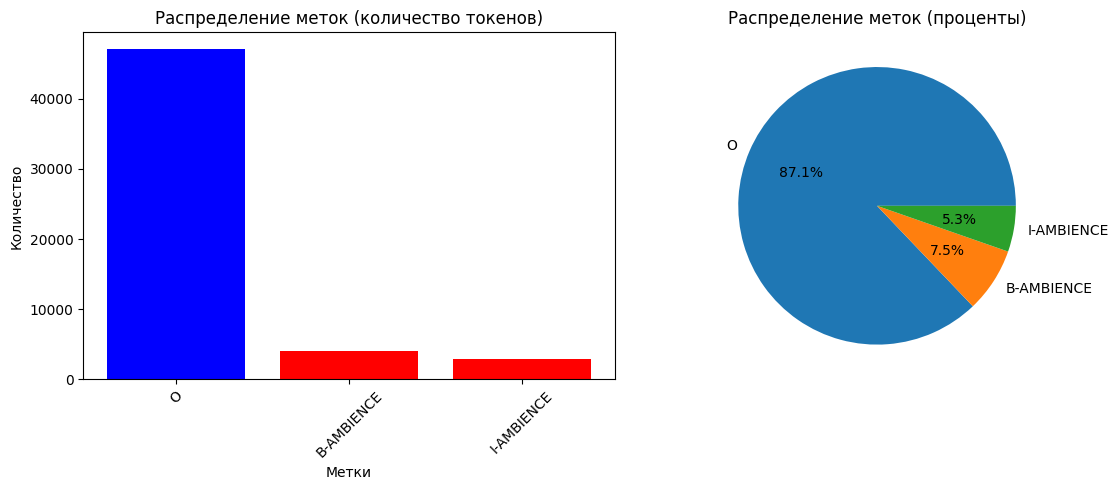


ВЫВОД:
✅ БАЗОВАЯ СТРУКТУРА TRAIN КОРРЕКТНА!
   Проблема может быть в другой части:
   - Неправильная загрузка меток в модель
   - Недостаточно эпох обучения
   - Слишком маленький learning rate


In [68]:
from collections import Counter
import matplotlib.pyplot as plt

def analyze_bio_labels(file_path):
    """Анализирует распределение меток в BIO-файле"""
    label_counter = Counter()
    token_counter = 0
    
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                parts = line.split()
                if len(parts) >= 2:
                    label = parts[1]
                    label_counter[label] += 1
                    token_counter += 1
    
    return label_counter, token_counter

# Анализируем train.txt
print("=" * 70)
print("АНАЛИЗ РАЗМЕТКИ В TRAIN.TXT")
print("=" * 70)

train_stats, total_tokens = analyze_bio_labels('train.txt')

print(f"\n📊 Общее количество токенов: {total_tokens:,}")
print(f"\n📈 Распределение меток:")
print("-" * 70)
print(f"{'Метка':<20} {'Количество':<12} {'Процент':<10} {'Визуализация'}")
print("-" * 70)

# Сортируем по убыванию
for label, count in sorted(train_stats.items(), key=lambda x: x[1], reverse=True):
    percentage = count / total_tokens * 100
    bar = "█" * int(percentage / 2)  # Масштабируем для красоты
    print(f"{label:<20} {count:<12,} {percentage:>6.2f}%     {bar}")

print("-" * 70)

# Специальный анализ для атмосферных меток
print("\n" + "=" * 70)
print("АНАЛИЗ ТОЛЬКО АТМОСФЕРНЫХ МЕТОК")
print("=" * 70)

# Считаем только метки, связанные с атмосферой
ambience_labels = {k: v for k, v in train_stats.items() if k != 'O'}
total_ambience = sum(ambience_labels.values())

if total_ambience > 0:
    print(f"\n🎯 Всего токенов с атмосферой: {total_ambience:,} ({total_ambience/total_tokens*100:.2f}% от всех)")
    
    for label, count in sorted(ambience_labels.items()):
        percentage_of_ambience = count / total_ambience * 100
        percentage_of_total = count / total_tokens * 100
        print(f"\n  {label}:")
        print(f"    - {count:,} токенов")
        print(f"    - {percentage_of_ambience:.1f}% от всех атмосферных меток")
        print(f"    - {percentage_of_total:.2f}% от всех токенов")
    
    # Проверяем соотношение B и I
    b_count = train_stats.get('B-AMBIENCE', 0)
    i_count = train_stats.get('I-AMBIENCE', 0)
    
    print(f"\n📊 Соотношение B-AMBIENCE : I-AMBIENCE")
    print(f"   B: {b_count}")
    print(f"   I: {i_count}")
    
    if b_count > 0:
        ratio = i_count / b_count
        print(f"   Соотношение: 1 : {ratio:.1f}")
        
        if ratio > 3:
            print(f"\n⚠️  ПРОБЛЕМА: I-AMBIENCE в {ratio:.1f} раз больше B-AMBIENCE!")
            print("   Это означает, что много слов размечены как продолжение без начала.")
            print("   Модель не может научиться правильно распознавать начало слов.")
        elif ratio < 0.5:
            print(f"\n⚠️  ПРОБЛЕМА: B-AMBIENCE больше чем I-AMBIENCE!")
            print("   Это означает, что почти все слова атмосферы состоят из одного токена.")
            print("   Но ruBERT разбивает слова на субтокены, поэтому должны быть I-метки.")
    else:
        print(f"\n❌ КРИТИЧЕСКАЯ ПРОБЛЕМА: Нет ни одной B-AMBIENCE метки в обучающем наборе!")
        print("   Модель никогда не видела начала слов атмосферы, поэтому не может их распознать.")
else:
    print("\n❌ НЕТ НИ ОДНОЙ АТМОСФЕРНОЙ МЕТКИ!")

# Подсчитываем количество предложений с атмосферой
print("\n" + "=" * 70)
print("АНАЛИЗ ПО ПРЕДЛОЖЕНИЯМ")
print("=" * 70)

sentences_with_ambience = 0
total_sentences = 0
current_sentence_has_ambience = False

with open('train.txt', 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            if current_sentence_has_ambience:
                sentences_with_ambience += 1
            total_sentences += 1
            current_sentence_has_ambience = False
        else:
            parts = line.split()
            if len(parts) >= 2 and parts[1] != 'O':
                current_sentence_has_ambience = True

if current_sentence_has_ambience:
    sentences_with_ambience += 1
    total_sentences += 1

print(f"\n📄 Всего предложений в train: {total_sentences}")
print(f"🎯 Предложений с атмосферой: {sentences_with_ambience} ({sentences_with_ambience/total_sentences*100:.1f}%)")
print(f"❌ Предложений без атмосферы: {total_sentences - sentences_with_ambience} ({(total_sentences-sentences_with_ambience)/total_sentences*100:.1f}%)")

# Визуализация
print("\n" + "=" * 70)
print("ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ")
print("=" * 70)

# Создаем простую ASCII-диаграмму
print("\nРаспределение всех меток:")
for label, count in sorted(train_stats.items(), key=lambda x: x[1], reverse=True):
    percentage = count / total_tokens * 100
    bar_length = int(percentage / 2)
    bar = "█" * bar_length
    print(f"{label:12} {percentage:5.1f}% {bar}")

# Если есть matplotlib, можно создать график
try:
    import matplotlib.pyplot as plt
    
    labels = list(train_stats.keys())
    counts = list(train_stats.values())
    percentages = [c/total_tokens*100 for c in counts]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # График 1: Количество
    ax1.bar(labels, counts, color=['red' if l != 'O' else 'blue' for l in labels])
    ax1.set_title('Распределение меток (количество токенов)')
    ax1.set_xlabel('Метки')
    ax1.set_ylabel('Количество')
    ax1.tick_params(axis='x', rotation=45)
    
    # График 2: Проценты
    ax2.pie(percentages, labels=labels, autopct='%1.1f%%')
    ax2.set_title('Распределение меток (проценты)')
    
    plt.tight_layout()
    plt.show()
except:
    print("\n(Для графиков установите matplotlib: pip install matplotlib)")

print("\n" + "=" * 70)
print("ВЫВОД:")
print("=" * 70)

# Финальный вердикт
b_count = train_stats.get('B-AMBIENCE', 0)
i_count = train_stats.get('I-AMBIENCE', 0)

if b_count == 0:
    print("❌ TRAIN ТОЧНО НЕПРАВИЛЬНЫЙ! Нет ни одной B-AMBIENCE метки!")
    print("   Модель никогда не сможет научиться распознавать начало слов атмосферы.")
    print("   Нужно пересоздать датасет с правильной BIO-разметкой.")
elif i_count / b_count > 5:
    print("⚠️  TRAIN ИМЕЕТ ПРОБЛЕМЫ: Слишком много I-AMBIENCE без B-AMBIENCE.")
    print("   Возможно, много слов атмосферы размечены неправильно.")
    print("   Рекомендуется проверить и исправить разметку.")
else:
    print("✅ БАЗОВАЯ СТРУКТУРА TRAIN КОРРЕКТНА!")
    print("   Проблема может быть в другой части:")
    print("   - Неправильная загрузка меток в модель")
    print("   - Недостаточно эпох обучения")
    print("   - Слишком маленький learning rate")

In [69]:
from transformers import pipeline

# Замените это на свою собственную контрольную точку
model_checkpoint = "huggingface-course/bert-finetuned-ner"
token_classifier = pipeline(
    "token-classification", model=model_checkpoint, aggregation_strategy="simple"
)
token_classifier("My name is Sylvain and I work at Hugging Face in Brooklyn.")

c:\Users\krask\AppData\Local\Programs\Python\Python314\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\krask\.cache\huggingface\hub\models--huggingface-course--bert-finetuned-ner. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


KeyboardInterrupt: 

In [77]:
pip install pyabsa==1.12.5

ERROR: Ignored the following yanked versions: 1.8.8, 2.0.13
ERROR: Ignored the following versions that require a different python version: 2.4.3 Requires-Python >=3.10,<3.11
ERROR: Could not find a version that satisfies the requirement pyabsa==1.12.5 (from versions: 0.9.9a0, 1.1.1, 1.1.3, 1.1.7a1, 1.1.8, 1.1.9, 1.1.12, 1.1.13, 1.1.14, 1.1.16, 1.1.17, 1.1.18, 1.1.19, 1.1.20, 1.1.22, 1.1.23, 1.1.24, 1.2.0, 1.2.2, 1.2.3, 1.2.5, 1.2.6, 1.2.7, 1.2.8, 1.2.9, 1.2.10, 1.2.12, 1.2.13, 1.3.5, 1.3.11, 1.3.12, 1.3.13, 1.3.14, 1.3.15, 1.5, 1.5.1, 1.5.2, 1.5.3, 1.5.4, 1.6, 1.6.1, 1.6.2, 1.6.3, 1.6.4, 1.6.5, 1.6.6, 1.6.7, 1.6.8, 1.6.10, 1.6.11, 1.6.12, 1.6.14, 1.6.14.1, 1.6.15, 1.6.16, 1.6.17, 1.8.1, 1.8.2, 1.8.4, 1.8.5, 1.8.9, 1.8.10, 1.8.11, 1.8.12, 1.8.13, 1.8.14, 1.8.15, 1.8.18, 1.8.20, 1.8.21, 1.8.22, 1.8.23, 1.8.24, 1.8.25, 1.8.26, 1.8.28, 1.8.29, 1.8.30, 1.8.32, 1.8.33, 1.8.34, 1.8.35, 1.8.36, 1.8.37, 1.8.38, 1.8.39, 1.8.40, 1.8.41, 1.8.42, 1.8.43, 1.9.0, 1.9.1, 1.9.2, 1.9.3, 1.9.4, 1.9.5, 1.

Note: you may need to restart the kernel to use updated packages.


In [76]:
from pyabsa import AspectTermExtraction as ATEPC

# Установка: pip install -U pyabsa

# 1. Быстрый старт с pre-trained моделью (мультиязычная поддерживает русский)
aspect_extractor = ATEPC.AspectExtractor(
    'multilingual',  # мультиязычная модель, работает с русским
    auto_device=True
)

# 2. Тест на ваших данных
test_texts = [
    "Ищу рынок для ребенка, но сомневаюсь, что там будет уютно и чисто",
    "Нужно тихое место для организации рабочего пространства",
    "Атмосфера в кафе была очень дружелюбной и располагающей"
]

for text in test_texts:
    result = aspect_extractor.predict(text)
    print(f"Текст: {text}")
    print(f"Найденные аспекты: {result}")
    print("-" * 50)

[2026-05-06 16:45:31] (2.4.2) ********** Available ATEPC model checkpoints for Version:2.4.2 (this version) **********
[2026-05-06 16:45:31] (2.4.2) ********** Available ATEPC model checkpoints for Version:2.4.2 (this version) **********
[2026-05-06 16:45:31] (2.4.2) Downloading checkpoint:multilingual 
[2026-05-06 16:45:31] (2.4.2) Notice: The pretrained model are used for testing, it is recommended to train the model on your own custom datasets
[2026-05-06 16:45:31] (2.4.2) Checkpoint already downloaded, skip
[2026-05-06 16:45:31] (2.4.2) Load aspect extractor from checkpoints\ATEPC_MULTILINGUAL_CHECKPOINT
[2026-05-06 16:45:31] (2.4.2) config: checkpoints\ATEPC_MULTILINGUAL_CHECKPOINT\fast_lcf_atepc.config
[2026-05-06 16:45:31] (2.4.2) state_dict: checkpoints\ATEPC_MULTILINGUAL_CHECKPOINT\fast_lcf_atepc.state_dict
[2026-05-06 16:45:31] (2.4.2) model: None
[2026-05-06 16:45:31] (2.4.2) tokenizer: checkpoints\ATEPC_MULTILINGUAL_CHECKPOINT\fast_lcf_atepc.tokenizer


RuntimeError: Exception: No module named 'transformers.models.deberta_v2.tokenization_deberta_v2_fast' Fail to load the model from checkpoints\ATEPC_MULTILINGUAL_CHECKPOINT! 